# Cross-Architecture Comparison: GPT-OSS 20B · Qwen3-14B · Gemma 4 E4B
## Fine-Tuning on Jordan B. Peterson's Works — 6 Model Variants

This notebook performs the most complete comparison in this series, evaluating
**six model variants** side by side on the same prompts and metrics.

| # | Model | Architecture | Status |
|---|-------|-------------|--------|
| 1 | `unsloth/gpt-oss-20b-unsloth-bnb-4bit` | Harmony / GPT-4o-mini-flash | Base (pre-trained only) |
| 2 | `./outputs/gpt_oss_20b_jordan_peterson_lora` | Harmony / GPT-4o-mini-flash | Fine-tuned on 4 Peterson books, 1 epoch |
| 3 | `unsloth/Qwen3-14B-unsloth-bnb-4bit` | ChatML / Qwen3 | Base (pre-trained only) |
| 4 | `./outputs/qwen3_14b_jordan_peterson_lora` | ChatML / Qwen3 | Fine-tuned on 4 Peterson books, 1 epoch |
| 5 | `./outputs/qwen3_14b_peterson_v4_lora` | ChatML / Qwen3 | Fine-tuned — V4 (3 epochs, back-matter removed) |
| 6 | `./outputs/gemma4_e4b_peterson_v1_lora` | Gemma 4 / MoE | Fine-tuned — V1 (3 epochs, same V4 data) |

---
## Step 1: Imports and Configuration

In [1]:
import os, re, gc, math, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# ── Paths ──────────────────────────────────────────────────────────────────
GPTOSS_BASE_PATH   = "unsloth/gpt-oss-20b-unsloth-bnb-4bit"
GPTOSS_LORA_PATH   = "./outputs/gpt_oss_20b_jordan_peterson_lora"
QWEN3_BASE_PATH    = "unsloth/Qwen3-14B-unsloth-bnb-4bit"
QWEN3_LORA_PATH    = "./outputs/qwen3_14b_jordan_peterson_lora"
QWEN3_V4_PATH      = "./outputs/qwen3_14b_peterson_v4_lora"
GEMMA4_E4B_PATH    = "./outputs/gemma4_e4b_peterson_v1_lora"

CACHE_DIR   = Path("./comparison_cache_all_models")
FIGURES_DIR = Path("./comparison_figures_all_models")
CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ── Model registry ─────────────────────────────────────────────────────────
MODEL_KEYS   = ["gptoss_base", "gptoss_tuned", "qwen3_base", "qwen3_tuned",
                "qwen3_v4", "gemma4_e4b"]
MODEL_PATHS  = {
    "gptoss_base":  GPTOSS_BASE_PATH,
    "gptoss_tuned": GPTOSS_LORA_PATH,
    "qwen3_base":   QWEN3_BASE_PATH,
    "qwen3_tuned":  QWEN3_LORA_PATH,
    "qwen3_v4":     QWEN3_V4_PATH,
    "gemma4_e4b":   GEMMA4_E4B_PATH,
}
MODEL_SHORT  = {
    "gptoss_base":  "GPT-OSS 20B\nBase",
    "gptoss_tuned": "GPT-OSS 20B\nFine-Tuned",
    "qwen3_base":   "Qwen3-14B\nBase",
    "qwen3_tuned":  "Qwen3-14B\nV1",
    "qwen3_v4":     "Qwen3-14B\nV4",
    "gemma4_e4b":   "Gemma 4 E4B\nV1",
}
MODEL_DISPLAY = {
    "gptoss_base":  "GPT-OSS 20B  |  Base",
    "gptoss_tuned": "GPT-OSS 20B  |  Fine-Tuned",
    "qwen3_base":   "Qwen3-14B  |  Base",
    "qwen3_tuned":  "Qwen3-14B  |  V1 (1-ep completion)",
    "qwen3_v4":     "Qwen3-14B  |  V4 (3-ep, back-matter removed)",
    "gemma4_e4b":   "Gemma 4 E4B  |  V1 (3-ep, same V4 data)",
}
MODEL_COLORS = {
    "gptoss_base":  "#4C72B0",   # blue   — GPT-OSS base
    "gptoss_tuned": "#DD8452",   # orange — GPT-OSS fine-tuned
    "qwen3_base":   "#55A868",   # green  — Qwen3 base
    "qwen3_tuned":  "#C44E52",   # red    — Qwen3 V1
    "qwen3_v4":     "#8172B2",   # purple — Qwen3 V4
    "gemma4_e4b":   "#64B5CD",   # teal   — Gemma 4 E4B
}
CACHE_FILES = {k: CACHE_DIR / f"{k}_results.pkl" for k in MODEL_KEYS}

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

# ── System prompts ─────────────────────────────────────────────────────────
BASE_SYSTEM_PROMPT = "You are a helpful assistant."
TUNED_SYSTEM_PROMPT = (
    "You are an AI assistant that has been trained on the complete works of "
    "Jordan B. Peterson, a Canadian clinical psychologist, professor, and author. "
    "You speak with deep knowledge of psychology, philosophy, mythology, religion, "
    "and personal responsibility. Your responses reflect Peterson's writing style, "
    "intellectual depth, and interdisciplinary approach to understanding human "
    "nature and meaning."
)
SYSTEM_PROMPTS = {
    "gptoss_base":  BASE_SYSTEM_PROMPT,
    "gptoss_tuned": TUNED_SYSTEM_PROMPT,
    "qwen3_base":   BASE_SYSTEM_PROMPT,
    "qwen3_tuned":  TUNED_SYSTEM_PROMPT,
    "qwen3_v4":     TUNED_SYSTEM_PROMPT,
    "gemma4_e4b":   TUNED_SYSTEM_PROMPT,
}

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}  |  GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB total")
print(f"Cache    : {CACHE_DIR.resolve()}")
print(f"Figures  : {FIGURES_DIR.resolve()}")
print()
print("Cache status:")
for k in MODEL_KEYS:
    status = "EXISTS (will skip inference)" if CACHE_FILES[k].exists() else "missing (will run inference)"
    print(f"  {MODEL_DISPLAY[k]:<55}  {status}")

PyTorch  : 2.10.0+cu128
CUDA     : True  |  GPU: NVIDIA GeForce RTX 4090
VRAM     : 25.4 GB total
Cache    : /home/rob/PythonEnvironments/FineTuning/FineTuning/NoteBooks/JordanPeterson/comparison_cache_all_models
Figures  : /home/rob/PythonEnvironments/FineTuning/FineTuning/NoteBooks/JordanPeterson/comparison_figures_all_models

Cache status:
  GPT-OSS 20B  |  Base                                     EXISTS (will skip inference)
  GPT-OSS 20B  |  Fine-Tuned                               EXISTS (will skip inference)
  Qwen3-14B  |  Base                                       EXISTS (will skip inference)
  Qwen3-14B  |  V1 (1-ep completion)                       EXISTS (will skip inference)
  Qwen3-14B  |  V4 (3-ep, back-matter removed)             EXISTS (will skip inference)
  Gemma 4 E4B  |  V1 (3-ep, same V4 data)                  missing (will run inference)


---
## Step 2: Reference Data

Three types of reference data are used throughout this notebook:

- **2a — Peterson passages**: Verbatim text held out from training, used to measure
  *perplexity* (how surprised the model is by real Peterson sentences) and *TF-IDF
  similarity* (how closely model responses match his vocabulary distribution).
- **2b — Evaluation prompts**: Ten questions covering Peterson's core themes.
  Every model answers the same ten questions; metrics are computed per-prompt
  and then averaged for the summary charts.
- **2c — Keyword dictionary**: ~60 terms curated from the four books that are
  either exclusive to Peterson or unusually frequent in his writing. Used for
  keyword density (fraction of response words that are Peterson-signature words)  and the heatmap visualisation.

In [2]:
# ── 2a: Reference passages ─────────────────────────────────────────────────
# Eight short verbatim excerpts drawn from all four Peterson books, covering
# different themes (order/chaos, meaning, suffering, mythology, logos).
# They were NOT used as training examples — they come from later chapters or
# sections that were excluded from the fine-tuning dataset.
PETERSON_PASSAGES = [
    # From Maps of Meaning — the world as a forum for action
    "The world can be validly construed as a forum for action, or as a place of things. "
    "The former manner of interpretation — more primordial, and less clearly understood — "
    "finds its expression in the arts or humanities, in ritual, drama, literature, and myth. "
    "The world as forum for action is a place of value, a place where all things have meaning.",

    # From 12 Rules for Life — embodied courage
    "To stand up straight with your shoulders back is to accept the terrible responsibility "
    "of life, with eyes wide open. It means deciding to voluntarily transform the chaos of "
    "potential into the realities of habitable order. It means adopting the burden of "
    "self-conscious vulnerability, and accepting the end of the unconscious paradise of "
    "childhood, where finitude and mortality are only dimly comprehended.",

    # From Beyond Order — chaos as unexplored territory
    "Order is the place where the things you are currently doing are working out well "
    "for you. Chaos is the domain of ignorance itself. It's unexplored territory. Chaos "
    "is what extends, endlessly and without limit, beyond the boundaries of all states, "
    "all ideas, and all disciplines. It's the foreigner, the stranger, the member of "
    "another gang, the rustle in the bushes in the night-time.",

    # From We Who Wrestle with God — logos and truth
    "The divine spark in man is the logos — the word, the reason, the creative principle "
    "that gives order to the chaos of experience. To act in accordance with the logos is "
    "to speak the truth, to pursue what is meaningful rather than what is expedient, and "
    "to take on the burden of Being itself with courage and humility.",

    # From 12 Rules — compare yourself to who you were
    "Compare yourself to who you were yesterday, not to who someone else is today. "
    "You have a nature. You can play the game of life and improve. You can set a "
    "standard, even a minimal standard, and try to live up to it. You can improve "
    "incrementally, moving forward step by step. You can judge your life against "
    "what you know to be good, against what you should be.",

    # From Maps of Meaning — myth and the hero
    "The great myths and rituals of the past have been formulated in the language of "
    "the imagination. They say: act out the role of the hero; do not be the villain; "
    "do not be the tyrant. They say: update your maps of meaning when new information "
    "warrants it; admit your errors and change. They say: encounter the stranger and "
    "extract from that encounter what is valuable. Treat the stranger with respect.",

    # From Beyond Order — meaning as balance
    "Meaning is the ultimate balance between, on the one hand, the chaos of transformation "
    "and possibility and, on the other, the discipline of pristine order, whose purpose is "
    "to produce out of the attendant chaos a new order that will be even more productive "
    "and worthwhile than the old. Pursue what is meaningful, not what is expedient.",

    # From We Who Wrestle with God — suffering and transcendence
    "Suffering is not a mistake or an accident. It is the very ground of Being itself. "
    "To wrestle with God, as Jacob did, is to confront that suffering honestly, to take "
    "responsibility for it, and to find within it the possibility of transcendence. The "
    "hero does not flee from the dragon; he faces it and transforms the encounter.",
]

# ── 2b: Evaluation prompts ─────────────────────────────────────────────────
# Ten questions that span all four books' major themes. Identical prompts are
# used for every model so comparisons are strictly apples-to-apples.
EVAL_PROMPTS = [
    "What is the relationship between order and chaos in human experience?",
    "Why is personal responsibility the foundation of a meaningful life?",
    "How do ancient myths and stories reveal truths about human nature?",
    "What does it mean to pursue what is meaningful rather than what is expedient?",
    "How should a person confront suffering rather than flee from it?",
    "What is the significance of the hero archetype in understanding the human psyche?",
    "Why is telling the truth essential to a properly functioning life?",
    "What is the role of the divine or the sacred in organizing human society?",
    "How does the Jungian concept of the shadow relate to individual development?",
    "What does it mean to stand up straight with your shoulders back?",
]

# ── 2c: Peterson keyword dictionary ────────────────────────────────────────
# Curated terms that serve as proxies for Peterson's characteristic vocabulary.
# Using a keyword-density metric alongside TF-IDF gives us a more targeted
# measure: TF-IDF picks up general vocabulary similarity whereas keyword
# density specifically tracks his signature conceptual vocabulary.
PETERSON_KEYWORDS = list(set([
    # Core metaphysical concepts
    "chaos", "order", "logos", "being", "meaning", "meaningful", "meaningless",
    "transcendence", "transcendent", "archetype", "archetypal",
    # Jungian psychology
    "shadow", "anima", "animus", "unconscious", "consciousness", "psyche",
    "individuation", "projection",
    # Ethics and existentialism
    "responsibility", "suffering", "redemption", "courage", "virtue",
    "nihilism", "nihilistic", "expedient", "expedience", "tyranny", "tyrannical",
    "sovereignty", "heroic", "malevolent",
    # Narrative and mythology
    "myth", "mythological", "hero", "dragon", "narrative", "story",
    "ritual", "sacrifice", "resurrection", "transformation",
    # Religion and biblical imagery
    "divine", "sacred", "god", "biblical", "genesis", "logos", "spirit",
    "wrestle", "jacob", "adam", "eve", "serpent",
    # Peterson's distinctive action-language
    "confront", "hierarchy", "dominance", "voluntarily", "catastrophe",
    "pathological", "resentment", "ideological", "totalitarian",
]))

print(f"Reference passages  : {len(PETERSON_PASSAGES)}")
print(f"Evaluation prompts  : {len(EVAL_PROMPTS)}")
print(f"Keyword dictionary  : {len(PETERSON_KEYWORDS)} unique terms")

Reference passages  : 8
Evaluation prompts  : 10
Keyword dictionary  : 63 unique terms


---
## Step 3: Helper Functions

Two separate inference wrappers are defined — one for each model architecture —
because their chat-template APIs differ significantly:

| | GPT-OSS (Harmony) | Qwen3 (ChatML) |
|--|-------------------|----------------|
| Template call | `apply_chat_template(..., reasoning_effort="low", return_dict=True)` | `apply_chat_template(..., enable_thinking=False)` → plain string |
| Tokenization | Built into template call | Separate `tokenizer(text, ...)` step |
| Special cleanup | None needed | Strip residual `<think>…</think>` blocks |
| Token prefix | `<|start|>`, `<|message|>`, `<|end|>` | `<|im_start|>`, `<|im_end|>` |

The remaining helpers (`compute_perplexity`, `compute_text_stats`,
`compute_tfidf_similarity`) are architecture-independent and identical to those
used in the individual comparison notebooks.

In [3]:
def compute_perplexity(model, tokenizer, texts: list[str],
                       max_length: int = 256) -> list[float]:
    """
    Compute token-level perplexity for each text in the list.

    Uses the inner text tokenizer (tokenizer.tokenizer if available) to bypass
    the unsloth Gemma4Processor patch, which intercepts plain-string calls and
    tries to apply a chat template, returning None and crashing.

    Does NOT pass labels= to the model — Unsloth's fused CE loss allocates a
    ~1.5 GB gradient buffer for lm_head even under torch.no_grad(), causing OOM.
    Instead, logits are moved to CPU and CE loss is computed with F.cross_entropy.
    """
    # For Gemma4Processor (and other multimodal processors), use the inner text
    # tokenizer to avoid the unsloth chat-template patch intercepting plain strings.
    tok = getattr(tokenizer, 'tokenizer', tokenizer)
    model.eval()
    perplexities = []
    with torch.no_grad():
        for text in texts:
            enc = tok(
                text,
                return_tensors="pt",
                max_length=max_length,
                truncation=True,
            ).to("cuda")
            out = model(**enc)
            # Move logits to CPU to avoid Unsloth fused-CE VRAM overhead
            logits    = out.logits.cpu().float()   # (1, seq_len, vocab)
            input_ids = enc["input_ids"].cpu()     # (1, seq_len)
            # Shift: predict token[i+1] from logits at position i
            shift_logits = logits[0, :-1, :]       # (seq_len-1, vocab)
            shift_labels = input_ids[0, 1:]        # (seq_len-1,)
            loss = F.cross_entropy(shift_logits, shift_labels)
            perplexities.append(math.exp(loss.item()))
    return perplexities


def generate_response_gptoss(model, tokenizer, prompt: str,
                              system_prompt: str,
                              max_new_tokens: int = 300) -> str:
    """
    Generate a single response from a GPT-OSS (Harmony-format) model.

    The GPT-OSS tokenizer's apply_chat_template() accepts the Harmony-specific
    `reasoning_effort` parameter and returns a ready-to-use dict of tensors
    (input_ids + attention_mask) when return_dict=True.  We use 'low' effort
    to keep response length comparable to Qwen3's concise greedy outputs.

    Decoding is fully deterministic (do_sample=False) with a mild repetition
    penalty (1.1) to discourage looping on short or empty training examples.
    Only the *newly generated* tokens are decoded — we skip the prompt prefix
    by slicing out[0][input_ids.shape[1]:].
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
        reasoning_effort="low",   # Harmony-specific: keep responses concise
    ).to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy — fully deterministic
            temperature=1.0,          # ignored when do_sample=False, set for clarity
            repetition_penalty=1.1,   # mild penalty prevents token-loop collapse
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def generate_response_qwen3(model, tokenizer, prompt: str,
                             system_prompt: str,
                             max_new_tokens: int = 300) -> str:
    """
    Generate a single response from a Qwen3 (ChatML-format) model.

    Qwen3's apply_chat_template() requires a two-step process:
      1. Call apply_chat_template() with tokenize=False and enable_thinking=False
         to obtain a plain text string (not tensors).
      2. Pass that string to the tokenizer separately to get input_ids.

    Setting enable_thinking=False suppresses the chain-of-thought reasoning
    mode — Qwen3 can optionally prepend a <think>…</think> block before its
    response, which would contaminate our style-comparison metrics.
    Even with thinking disabled, the template sometimes adds empty
    <think>\n\n</think> artifacts, so we strip any such blocks with re.sub
    before returning the final string.
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    # Step 1: render the chat template → plain text
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,   # ChatML-specific: disable chain-of-thought
    )
    # Step 2: tokenise separately
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            repetition_penalty=1.1,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    # Strip any residual <think>…</think> blocks (may appear even with thinking disabled)
    response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    return response


def compute_text_stats(texts: list[str]) -> dict:
    """
    Compute per-text statistics over a list of model responses.

    IMPORTANT: every text in the list must contribute exactly one entry to
    each output list — even empty strings.  If we skip empties the lists
    will be shorter than len(texts), causing index-misalignment in the
    per-prompt bar charts.  Empty responses simply produce all-zero stats.

    Returns a dict with:
      word_counts     — number of alphabetic words per response
      sentence_counts — number of sentences per response
      ttr_values      — Type-Token Ratio = unique_words / total_words
      keyword_density — fraction of words that are Peterson keywords
      keyword_counts  — Counter of all keyword hits (for word-cloud / heatmap)
      all_words       — flat list of content words (stopwords removed)
    """
    stop_words = set(stopwords.words('english'))
    kw_set     = set(k.lower() for k in PETERSON_KEYWORDS)
    word_counts, sentence_counts, ttr_values = [], [], []
    keyword_density = []
    keyword_counts  = Counter()
    all_words       = []

    for text in texts:
        if text.strip():
            words = word_tokenize(text.lower())
            sents = sent_tokenize(text)
        else:
            words, sents = [], []   # empty response → all zeros; do NOT skip

        words_alpha = [w for w in words if w.isalpha()]
        word_counts.append(len(words_alpha))
        sentence_counts.append(len(sents))

        # TTR: higher = richer vocabulary; collapses for very short texts
        ttr = len(set(words_alpha)) / max(len(words_alpha), 1)
        ttr_values.append(ttr)

        # Peterson keyword density: fraction of words that are signature terms
        kw_hits = [w for w in words_alpha if w in kw_set]
        keyword_density.append(len(kw_hits) / max(len(words_alpha), 1))
        keyword_counts.update(kw_hits)

        # Content words for word cloud (strip stop words; keep length > 2)
        all_words.extend(w for w in words_alpha if w not in stop_words and len(w) > 2)

    return {
        "word_counts":     word_counts,
        "sentence_counts": sentence_counts,
        "ttr_values":      ttr_values,
        "keyword_density": keyword_density,
        "keyword_counts":  keyword_counts,
        "all_words":       all_words,
    }


def compute_tfidf_similarity(responses: list[str],
                              references: list[str]) -> list[float]:
    """
    Measure how similar each model response is to Peterson's actual writing
    using TF-IDF cosine similarity.

    TF-IDF weights words by how distinctive they are across the corpus —
    common words (the, and) get low weight; rare but frequent-within-author
    words (chaos, logos, archetype) get high weight.  Cosine similarity
    then measures the angle between the response vector and each reference
    vector; we return the maximum across all reference passages so that
    a response only needs to resemble *one* passage to score well.

    Responses that are empty (or nearly so) receive a similarity of 0.0,
    which accurately reflects their lack of Peterson-vocabulary content.
    """
    if not responses or not any(r.strip() for r in responses):
        return [0.0] * len(responses)
    all_texts  = references + responses
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    tfidf      = vectorizer.fit_transform(all_texts)
    ref_vecs   = tfidf[:len(references)]
    resp_vecs  = tfidf[len(references):]
    similarities = []
    for i in range(resp_vecs.shape[0]):
        sims = cosine_similarity(resp_vecs[i], ref_vecs)[0]
        similarities.append(float(sims.max()))
    return similarities



def generate_response_gemma4(model, tokenizer, prompt: str,
                              system_prompt: str,
                              max_new_tokens: int = 300) -> str:
    """
    Generate a single response from a Gemma 4 (FastModel) model.

    Gemma 4 uses the <start_of_turn>user / <start_of_turn>model token format.
    The system message is automatically prepended to the first user turn by the
    tokenizer's built-in chat template — we pass it as role "system" as normal.

    Uses tokenizer.tokenizer (inner text tokenizer) instead of the outer
    Gemma4Processor for apply_chat_template.  The Processor's override iterates
    over message["content"] expecting a list-of-dicts (multimodal format) and
    crashes with "string indices must be integers" when content is a plain string.
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    # Use the inner text tokenizer to bypass Gemma4Processor.apply_chat_template,
    # which expects multimodal content (list of dicts) not plain strings.
    tok = getattr(tokenizer, 'tokenizer', tokenizer)
    input_ids = tok.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")
    with torch.no_grad():
        out = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            repetition_penalty=1.1,
        )
    new_tokens = out[0][input_ids.shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()


def _avg(lst): return sum(lst) / len(lst) if lst else 0.0

print("Helper functions defined.")

Helper functions defined.


---
## Phase 1: GPT-OSS 20B — Base Model

We evaluate the *unmodified* GPT-OSS 20B model, which has never seen Peterson's
books.  It uses the generic `"You are a helpful assistant."` system prompt.

This establishes our **baseline** for the GPT-OSS architecture: any improvement
in the fine-tuned variant (Phase 2) can be attributed directly to the LoRA
training on the four Peterson books.

In [4]:
from unsloth import FastLanguageModel

_cache = CACHE_FILES["gptoss_base"]

if _cache.exists():
    # ── Fast path: skip model loading entirely ─────────────────────────────
    # Loading a 20B model takes ~60 seconds and consumes ~14 GB of VRAM.
    # If we already ran inference and saved the pkl, we bypass all of that.
    print(f"Cache found — skipping GPT-OSS 20B Base inference.")
    print(f"  {_cache}")
else:
    # ── Slow path: load → infer → save → unload ────────────────────────────
    print("Loading GPT-OSS 20B Base model …")
    _model, _tok = FastLanguageModel.from_pretrained(
        model_name      = GPTOSS_BASE_PATH,
        dtype           = None,    # auto (bfloat16 on Ampere+, float16 otherwise)
        max_seq_length  = 2048,    # matches the max used during fine-tuning
        load_in_4bit    = True,    # bitsandbytes 4-bit quantization to save VRAM
        full_finetuning = False,   # inference-only; no adapter merging needed
    )
    FastLanguageModel.for_inference(_model)   # Unsloth: 2× faster inference kernel
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    # ── 1a. Perplexity on held-out Peterson passages ────────────────────────
    print("\nComputing perplexity on reference passages …")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    # ── 1b. Generate responses to all 10 evaluation prompts ────────────────
    # We use the architecture-appropriate wrapper (generate_response_gptoss).
    # The generic BASE_SYSTEM_PROMPT is used because the base model has not
    # been conditioned to write like Peterson.
    print("\nGenerating responses …")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_gptoss(_model, _tok, prompt,
                                     SYSTEM_PROMPTS["gptoss_base"])
        _resps.append(r)
        print(f"         → {r[:100]}\n")

    # ── 1c. Persist results and free VRAM ──────────────────────────────────
    # We save a dict containing both lists so a single pkl read in the metrics
    # cell restores the full results for this model.
    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved → {_cache}")

    # Explicitly delete model references and flush CUDA memory allocator.
    # Without this step, loading the next 20B model would likely OOM.
    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

# ── Always load pkl into named variables ───────────────────────────────────
with open(_cache, "rb") as f:
    _d = pickle.load(f)
gptoss_base_responses    = _d["responses"]
gptoss_base_perplexities = _d["perplexities"]
print(f"\nGPT-OSS 20B Base loaded from cache.")
print(f"  Responses    : {len(gptoss_base_responses)}")
print(f"  Avg PPL      : {_avg(gptoss_base_perplexities):.2f}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Cache found — skipping GPT-OSS 20B Base inference.
  comparison_cache_all_models/gptoss_base_results.pkl

GPT-OSS 20B Base loaded from cache.
  Responses    : 10
  Avg PPL      : 31.09


---
## Phase 2: GPT-OSS 20B — Fine-Tuned Model

We now load the LoRA-adapted version of the same GPT-OSS 20B model, trained for
**1 epoch** on ~768,000 words from four Peterson books:
*Maps of Meaning*, *12 Rules for Life*, *Beyond Order*, and
*We Who Wrestle with God*.

Training stats: **641 steps**, **73.3 min**, **loss 3.01**, batch size 1.

The fine-tuned model uses the rich Peterson system prompt to activate its
domain-specific weights. We use the same Harmony-format `generate_response_gptoss`
wrapper as the base model — the only difference is the model weights loaded.

In [5]:
_cache = CACHE_FILES["gptoss_tuned"]

if _cache.exists():
    print(f"Cache found — skipping GPT-OSS 20B Fine-Tuned inference.")
    print(f"  {_cache}")
else:
    # Unsloth loads LoRA adapters transparently: passing the adapter directory
    # as model_name causes it to detect the adapter config and merge the LoRA
    # weights onto the base model at load time.  No separate merge step needed.
    print("Loading GPT-OSS 20B Fine-Tuned model (base + LoRA adapters) …")
    _model, _tok = FastLanguageModel.from_pretrained(
        model_name      = GPTOSS_LORA_PATH,   # points to saved adapter directory
        dtype           = None,
        max_seq_length  = 2048,
        load_in_4bit    = True,
        full_finetuning = False,
    )
    FastLanguageModel.for_inference(_model)
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    print("\nComputing perplexity on reference passages …")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    # Fine-tuned model receives the TUNED system prompt — the same persona
    # prompt it was trained on — to ensure we evaluate it under its intended
    # operating conditions.
    print("\nGenerating responses …")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_gptoss(_model, _tok, prompt,
                                     SYSTEM_PROMPTS["gptoss_tuned"])
        _resps.append(r)
        print(f"         → {r[:100]}\n")

    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved → {_cache}")

    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

with open(_cache, "rb") as f:
    _d = pickle.load(f)
gptoss_tuned_responses    = _d["responses"]
gptoss_tuned_perplexities = _d["perplexities"]
print(f"\nGPT-OSS 20B Fine-Tuned loaded from cache.")
print(f"  Responses    : {len(gptoss_tuned_responses)}")
print(f"  Avg PPL      : {_avg(gptoss_tuned_perplexities):.2f}")

Cache found — skipping GPT-OSS 20B Fine-Tuned inference.
  comparison_cache_all_models/gptoss_tuned_results.pkl

GPT-OSS 20B Fine-Tuned loaded from cache.
  Responses    : 10
  Avg PPL      : 15.29


---
## Phase 3: Qwen3-14B — Base Model

Qwen3-14B is a **different architecture** from GPT-OSS — Alibaba's third-generation
Qwen model using the ChatML format (`<|im_start|>` / `<|im_end|>` tokens) and
supporting an optional chain-of-thought thinking mode via `enable_thinking`.

At 14B parameters vs 20B for GPT-OSS, Qwen3 is a *smaller* model — yet it
achieves a lower training loss after 1 epoch (2.44 vs 3.01).  This phase
evaluates whether the smaller model is already more capable on Peterson-domain
questions *before* fine-tuning, which would favour Qwen3 architecturally.

Key API difference: `generate_response_qwen3` uses a two-step tokenization
pipeline and strips any `<think>` blocks from the output.

In [6]:
_cache = CACHE_FILES["qwen3_base"]

if _cache.exists():
    print(f"Cache found — skipping Qwen3-14B Base inference.")
    print(f"  {_cache}")
else:
    # Qwen3-14B in 4-bit quantization uses ~10.4 GB of VRAM — less than
    # GPT-OSS 20B but still substantial. We follow the same load/infer/
    # save/unload pattern to keep memory usage predictable.
    print("Loading Qwen3-14B Base model …")
    _model, _tok = FastLanguageModel.from_pretrained(
        model_name      = QWEN3_BASE_PATH,
        dtype           = None,
        max_seq_length  = 2048,
        load_in_4bit    = True,
        full_finetuning = False,
    )
    FastLanguageModel.for_inference(_model)
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    print("\nComputing perplexity on reference passages …")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    # Qwen3's generate_response wrapper applies the ChatML template with
    # enable_thinking=False, tokenises separately, and strips any <think> tags.
    print("\nGenerating responses …")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_qwen3(_model, _tok, prompt,
                                    SYSTEM_PROMPTS["qwen3_base"])
        _resps.append(r)
        print(f"         → {r[:100]}\n")

    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved → {_cache}")

    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

with open(_cache, "rb") as f:
    _d = pickle.load(f)
qwen3_base_responses    = _d["responses"]
qwen3_base_perplexities = _d["perplexities"]
print(f"\nQwen3-14B Base loaded from cache.")
print(f"  Responses    : {len(qwen3_base_responses)}")
print(f"  Avg PPL      : {_avg(qwen3_base_perplexities):.2f}")

Cache found — skipping Qwen3-14B Base inference.
  comparison_cache_all_models/qwen3_base_results.pkl

Qwen3-14B Base loaded from cache.
  Responses    : 10
  Avg PPL      : 19.36


---
## Phase 4: Qwen3-14B — Fine-Tuned Model

The Qwen3-14B model fine-tuned on the same four Peterson books.

Training stats: **321 steps**, **23.3 min**, **loss 2.44**, batch size 2.

Notable: despite being a smaller model, Qwen3 reached a *lower* training loss
in a *third* of the time and with *half* as many gradient updates.  Whether
this superior training efficiency translates to better inference quality is
exactly what this phase (and the subsequent comparisons) will reveal.

In [7]:
_cache = CACHE_FILES["qwen3_tuned"]

if _cache.exists():
    print(f"Cache found — skipping Qwen3-14B Fine-Tuned inference.")
    print(f"  {_cache}")
else:
    print("Loading Qwen3-14B Fine-Tuned model (base + LoRA adapters) …")
    _model, _tok = FastLanguageModel.from_pretrained(
        model_name      = QWEN3_LORA_PATH,
        dtype           = None,
        max_seq_length  = 2048,
        load_in_4bit    = True,
        full_finetuning = False,
    )
    FastLanguageModel.for_inference(_model)
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    print("\nComputing perplexity on reference passages …")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    print("\nGenerating responses …")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_qwen3(_model, _tok, prompt,
                                    SYSTEM_PROMPTS["qwen3_tuned"])
        _resps.append(r)
        print(f"         → {r[:100]}\n")

    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved → {_cache}")

    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

with open(_cache, "rb") as f:
    _d = pickle.load(f)
qwen3_tuned_responses    = _d["responses"]
qwen3_tuned_perplexities = _d["perplexities"]
print(f"\nQwen3-14B Fine-Tuned loaded from cache.")
print(f"  Responses    : {len(qwen3_tuned_responses)}")
print(f"  Avg PPL      : {_avg(qwen3_tuned_perplexities):.2f}")

Cache found — skipping Qwen3-14B Fine-Tuned inference.
  comparison_cache_all_models/qwen3_tuned_results.pkl

Qwen3-14B Fine-Tuned loaded from cache.
  Responses    : 10
  Avg PPL      : 12.94


---
## Phase 5: Qwen3-14B — V4 Fine-Tuned (3 epochs, front+back-matter removed)

V4 represents the cleanest Qwen3 fine-tuning in this series. Unlike V1 (1 epoch,
passage-completion training), V4 uses:
- **Synthetic Q&A pairs** — training task matches the inference task
- **3 epochs** — more gradient updates than V1's single pass
- **Front + back-matter removed** — 3,936 pairs from content-only pages;
  no publisher pages, no index pages, no endnotes

Training stats: **1,476 steps**, **98.0 min**, **loss 1.6421**, peak VRAM 13.9 GB.

Key result from prior evaluation: **0/5 eval prompts produce index output** — the
primary contamination problem in V3 (3/5) is fully resolved.

This phase answers research question 5: does better training data + more epochs
produce meaningfully different metrics than V1 in the cross-architecture comparison?

In [8]:
_cache = CACHE_FILES["qwen3_v4"]

if _cache.exists():
    print(f"Cache found — skipping Qwen3-14B V4 inference.")
    print(f"  {_cache}")
else:
    print("Loading Qwen3-14B V4 model (base + LoRA adapters) ...")
    _model, _tok = FastLanguageModel.from_pretrained(
        model_name      = MODEL_PATHS["qwen3_v4"],
        dtype           = None,
        max_seq_length  = 2048,
        load_in_4bit    = True,
        full_finetuning = False,
    )
    FastLanguageModel.for_inference(_model)
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    print("\nComputing perplexity on reference passages ...")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    print("\nGenerating responses ...")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_qwen3(_model, _tok, prompt,
                                    SYSTEM_PROMPTS["qwen3_v4"])
        _resps.append(r)
        print(f"         -> {r[:100]}\n")

    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved -> {_cache}")

    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

with open(_cache, "rb") as f:
    _d = pickle.load(f)
qwen3_v4_responses    = _d["responses"]
qwen3_v4_perplexities = _d["perplexities"]
print(f"\nQwen3-14B V4 loaded from cache.")
print(f"  Responses    : {len(qwen3_v4_responses)}")
print(f"  Avg PPL      : {_avg(qwen3_v4_perplexities):.2f}")

Cache found — skipping Qwen3-14B V4 inference.
  comparison_cache_all_models/qwen3_v4_results.pkl

Qwen3-14B V4 loaded from cache.
  Responses    : 10
  Avg PPL      : 11.27


---
## Phase 6: Gemma 4 E4B — Fine-Tuned Model

Google's Gemma 4 E4B uses a Mixture-of-Experts architecture with ~4B *effective*
active parameters per forward pass, drawn from a much larger total model.

Training stats: see `Gemma4_E4B_JordanPeterson_FineTuning.ipynb` for full
results after training.  The fine-tuning used the same V4 data (3,936 pairs)
and 3 epochs as Qwen3-14B V4.

**Note on expected loss**: E2B/E4B models show loss 13–15 during training (a known
characteristic of small MoE models), NOT the 1–3 range seen in 26B/31B variants.
This does not mean training failed — the model still learns the fine-tuning signal.

**Inference API**: Gemma 4 uses `FastModel` (not `FastLanguageModel`) and the
`<start_of_turn>user / <start_of_turn>model` Gemma 3-compatible chat format.

In [9]:
from unsloth import FastModel

_cache = CACHE_FILES["gemma4_e4b"]

if _cache.exists():
    print(f"Cache found — skipping Gemma 4 E4B inference.")
    print(f"  {_cache}")
else:
    print("Loading Gemma 4 E4B Fine-Tuned model (base + LoRA adapters) ...")
    _model, _tok = FastModel.from_pretrained(
        model_name      = MODEL_PATHS["gemma4_e4b"],
        dtype           = None,
        max_seq_length  = 2048,
        load_in_4bit    = True,
        full_finetuning = False,
    )
    FastModel.for_inference(_model)
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

    print("\nComputing perplexity on reference passages ...")
    _ppls = compute_perplexity(_model, _tok, PETERSON_PASSAGES)
    print(f"  Per-passage: {[round(p,1) for p in _ppls]}")
    print(f"  Average    : {_avg(_ppls):.2f}")

    print("\nGenerating responses ...")
    _resps = []
    for i, prompt in enumerate(EVAL_PROMPTS):
        print(f"  [{i+1:02d}/{len(EVAL_PROMPTS)}] {prompt[:70]}")
        r = generate_response_gemma4(_model, _tok, prompt,
                                     SYSTEM_PROMPTS["gemma4_e4b"])
        _resps.append(r)
        print(f"         -> {r[:100]}\n")

    with open(_cache, "wb") as f:
        pickle.dump({"responses": _resps, "perplexities": _ppls}, f)
    print(f"\nSaved -> {_cache}")

    del _model, _tok, _resps, _ppls
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Model unloaded.  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

with open(_cache, "rb") as f:
    _d = pickle.load(f)
gemma4_e4b_responses    = _d["responses"]
gemma4_e4b_perplexities = _d["perplexities"]
print(f"\nGemma 4 E4B loaded from cache.")
print(f"  Responses    : {len(gemma4_e4b_responses)}")
print(f"  Avg PPL      : {_avg(gemma4_e4b_perplexities):.2f}")

Loading Gemma 4 E4B Fine-Tuned model (base + LoRA adapters) ...
==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.635 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

  VRAM reserved: 10.3 GB

Computing perplexity on reference passages ...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  Per-passage: [6223.1, 4586.9, 2704.8, 1350.4, 1648.0, 3574.0, 2864.6, 3523.0]
  Average    : 3309.34

Generating responses ...
  [01/10] What is the relationship between order and chaos in human experience?
         -> the world as it is, not as it could be. This is the attitude of the victim, who believes that some f

  [02/10] Why is personal responsibility the foundation of a meaningful life?
         -> the world as you see it, not as someone else wants it to be. That’s your vision. It’s yours. It’s no

  [03/10] How do ancient myths and stories reveal truths about human nature?
         -> the world as it is, not as it could be. The story of the flood is not a scientific account of some h

  [04/10] What does it mean to pursue what is meaningful rather than what is exp
         -> the future, as you know it, and the past, as you remember it. But you don’t. You do. And you will. B

  [05/10] How should a person confront suffering rather than flee from it?
         -> the world as

---
## Step 5: Aggregate All Metrics

Now that all five pkl files have been loaded, we compute the remaining metrics
(TF-IDF similarity and text statistics) for every model at once.  No GPU is
required at this point — all computation is CPU-bound.

In [21]:
# ── Consolidate all response and perplexity lists into dicts ───────────────
all_responses = {
    "gptoss_base":  gptoss_base_responses,
    "gptoss_tuned": gptoss_tuned_responses,
    "qwen3_base":   qwen3_base_responses,
    "qwen3_tuned":  qwen3_tuned_responses,
    "qwen3_v4":     qwen3_v4_responses,
    "gemma4_e4b":   gemma4_e4b_responses,
}
all_perplexities = {
    "gptoss_base":  gptoss_base_perplexities,
    "gptoss_tuned": gptoss_tuned_perplexities,
    "qwen3_base":   qwen3_base_perplexities,
    "qwen3_tuned":  qwen3_tuned_perplexities,
    "qwen3_v4":     qwen3_v4_perplexities,
    "gemma4_e4b":   gemma4_e4b_perplexities,
}

print("Computing TF-IDF similarities ...")
all_similarities = {
    k: compute_tfidf_similarity(all_responses[k], PETERSON_PASSAGES)
    for k in MODEL_KEYS
}

print("Computing text statistics ...")
all_stats = {k: compute_text_stats(all_responses[k]) for k in MODEL_KEYS}

avg_ppl  = {k: _avg(all_perplexities[k])              for k in MODEL_KEYS}
avg_sim  = {k: _avg(all_similarities[k])               for k in MODEL_KEYS}
avg_kd   = {k: _avg(all_stats[k]["keyword_density"])   for k in MODEL_KEYS}
avg_ttr  = {k: _avg(all_stats[k]["ttr_values"])        for k in MODEL_KEYS}
avg_len  = {k: _avg(all_stats[k]["word_counts"])       for k in MODEL_KEYS}

w = 13
print()
print(f"{'Metric':<30} {'GPT-OSS B':>{w}} {'GPT-OSS FT':>{w}} {'Qwen3 B':>{w}} {'Qwen3 V1':>{w}} {'Qwen3 V4':>{w}} {'Gemma4 E4B':>{w}}")
print("\u2500" * (30 + 6 * (w + 1)))
print(f"{'Avg Perplexity':<30} {avg_ppl['gptoss_base']:>{w}.2f} {avg_ppl['gptoss_tuned']:>{w}.2f} {avg_ppl['qwen3_base']:>{w}.2f} {avg_ppl['qwen3_tuned']:>{w}.2f} {avg_ppl['qwen3_v4']:>{w}.2f} {avg_ppl['gemma4_e4b']:>{w}.2f}")
print(f"{'Avg TF-IDF Similarity':<30} {avg_sim['gptoss_base']:>{w}.4f} {avg_sim['gptoss_tuned']:>{w}.4f} {avg_sim['qwen3_base']:>{w}.4f} {avg_sim['qwen3_tuned']:>{w}.4f} {avg_sim['qwen3_v4']:>{w}.4f} {avg_sim['gemma4_e4b']:>{w}.4f}")
print(f"{'Avg Keyword Density':<30} {100*avg_kd['gptoss_base']:>{w-1}.2f}% {100*avg_kd['gptoss_tuned']:>{w-1}.2f}% {100*avg_kd['qwen3_base']:>{w-1}.2f}% {100*avg_kd['qwen3_tuned']:>{w-1}.2f}% {100*avg_kd['qwen3_v4']:>{w-1}.2f}% {100*avg_kd['gemma4_e4b']:>{w-1}.2f}%")
print(f"{'Avg TTR':<30} {avg_ttr['gptoss_base']:>{w}.4f} {avg_ttr['gptoss_tuned']:>{w}.4f} {avg_ttr['qwen3_base']:>{w}.4f} {avg_ttr['qwen3_tuned']:>{w}.4f} {avg_ttr['qwen3_v4']:>{w}.4f} {avg_ttr['gemma4_e4b']:>{w}.4f}")
print(f"{'Avg Response Length (words)':<30} {avg_len['gptoss_base']:>{w}.1f} {avg_len['gptoss_tuned']:>{w}.1f} {avg_len['qwen3_base']:>{w}.1f} {avg_len['qwen3_tuned']:>{w}.1f} {avg_len['qwen3_v4']:>{w}.1f} {avg_len['gemma4_e4b']:>{w}.1f}")
print("\u2500" * (30 + 6 * (w + 1)))

Computing TF-IDF similarities ...
Computing text statistics ...

Metric                             GPT-OSS B    GPT-OSS FT       Qwen3 B      Qwen3 V1      Qwen3 V4    Gemma4 E4B
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Avg Perplexity                         31.09         15.29         19.36         12.94         11.27       3309.34
Avg TF-IDF Similarity                 0.0511        0.0090        0.0607        0.0535        0.0374        0.0372
Avg Keyword Density                    3.54%         0.73%         4.19%         3.30%         1.79%         1.50%
Avg TTR                               0.7691        0.0508        0.6614        0.3801        0.6294        0.4232
Avg Response Length (words)            180.5          54.6         204.4         250.3         238.4         252.1
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────


---
## Figure 1: Perplexity on Peterson Reference Passages

**Left panel** — Per-passage perplexity for all four models.  Each cluster of
four bars corresponds to one held-out reference passage.  We expect both
fine-tuned models to sit lower in their respective clusters.

**Right panel** — Average perplexity across all eight passages.  This is the
single most direct measure of domain adaptation: lower = more "in-domain".

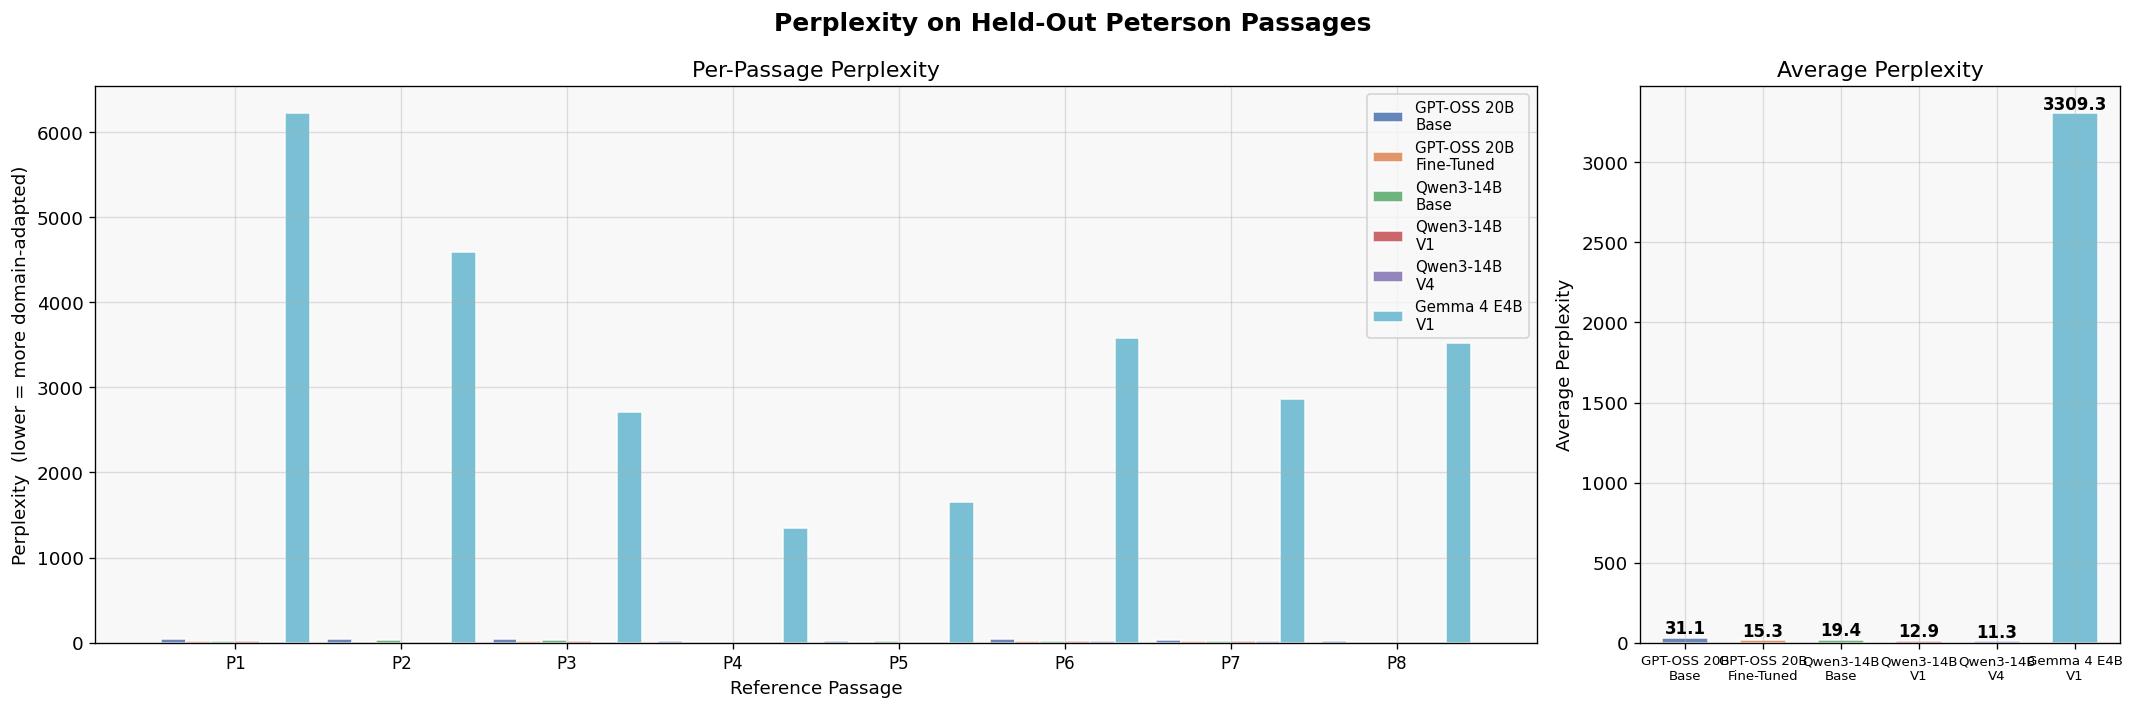

Saved: 01_perplexity.png


In [22]:
x      = np.arange(len(PETERSON_PASSAGES))
width  = 0.15
n      = len(MODEL_KEYS)
colors = [MODEL_COLORS[k] for k in MODEL_KEYS]
labels = [MODEL_SHORT[k]  for k in MODEL_KEYS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6),
                                gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle("Perplexity on Held-Out Peterson Passages", fontsize=15, fontweight='bold')

for i, (key, color, label) in enumerate(zip(MODEL_KEYS, colors, labels)):
    offset = (i - (n - 1) / 2) * width
    ax1.bar(x + offset, all_perplexities[key], width,
            label=label, color=color, alpha=0.85, edgecolor='white')
ax1.set_xlabel("Reference Passage")
ax1.set_ylabel("Perplexity  (lower = more domain-adapted)")
ax1.set_title("Per-Passage Perplexity")
ax1.set_xticks(x)
ax1.set_xticklabels([f"P{i+1}" for i in range(len(PETERSON_PASSAGES))], fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.4)

avgs = [avg_ppl[k] for k in MODEL_KEYS]
bars = ax2.bar(range(n), avgs, color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.2,
             f"{v:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(range(n))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("Average Perplexity")
ax2.set_title("Average Perplexity")
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_perplexity.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 01_perplexity.png")

---
## Figure 2: TF-IDF Cosine Similarity to Peterson's Writing

For each model response to each evaluation prompt, we compute the cosine
similarity between its TF-IDF vector and each of the eight reference passages,
then take the *maximum* — so a response only needs to resemble one passage to
score well.

**Higher = the model's word choices are more similar to how Peterson actually writes.**

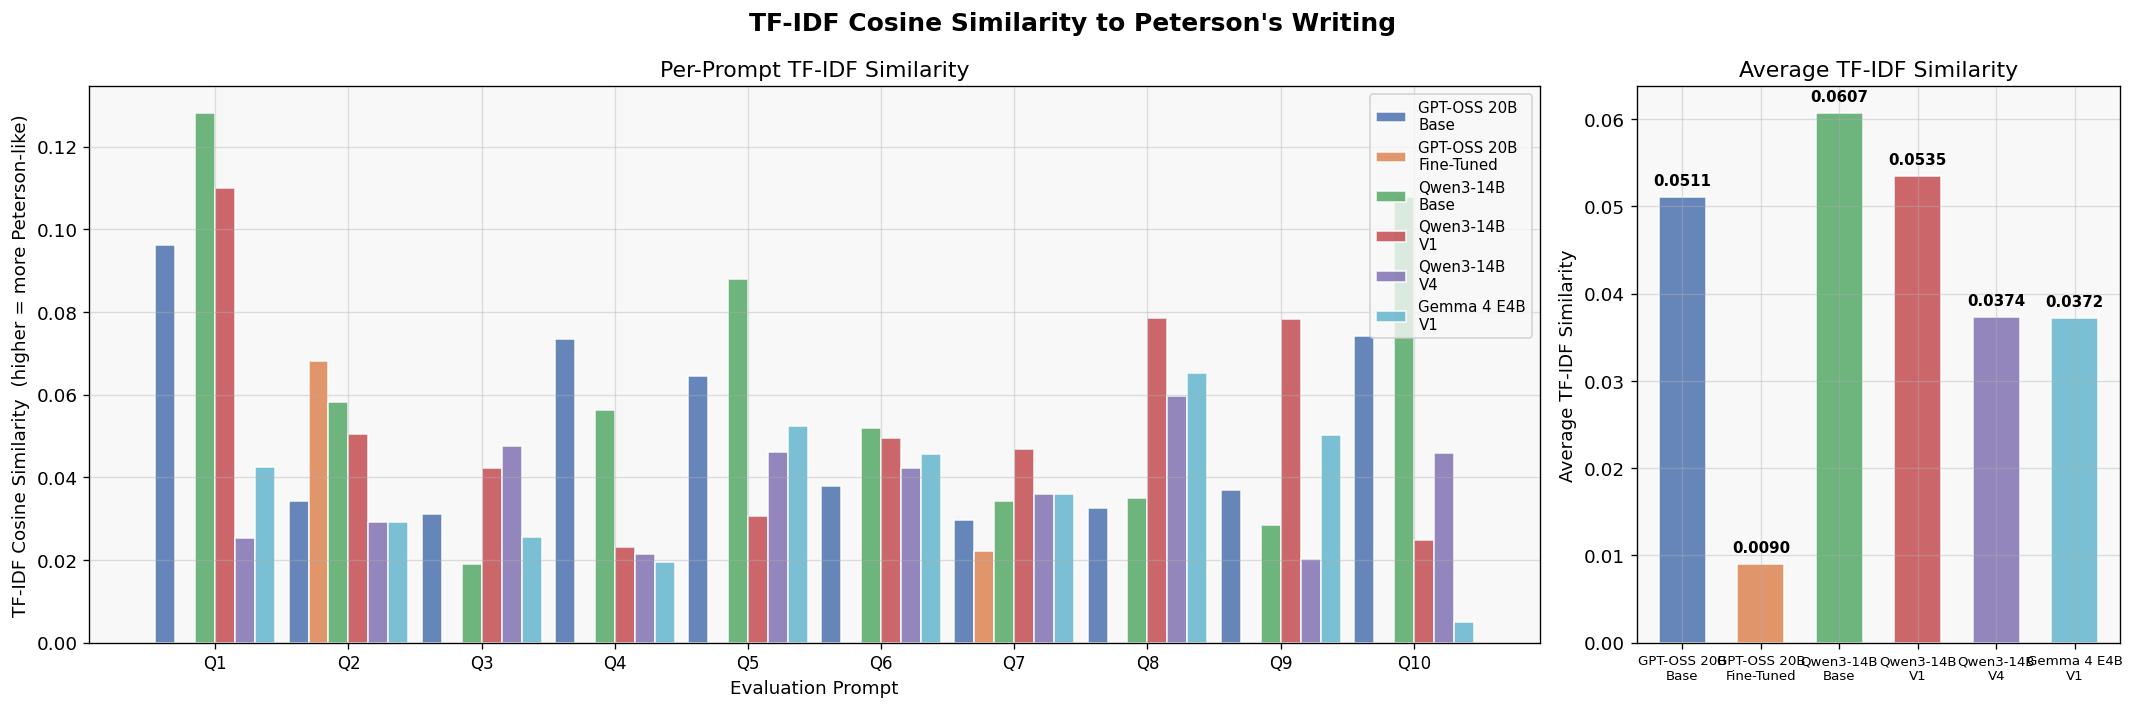

Saved: 02_tfidf_similarity.png


In [23]:
x     = np.arange(len(EVAL_PROMPTS))
width = 0.15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6),
                                gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle("TF-IDF Cosine Similarity to Peterson's Writing",
             fontsize=15, fontweight='bold')

for i, (key, color, label) in enumerate(zip(MODEL_KEYS, colors, labels)):
    offset = (i - (n - 1) / 2) * width
    ax1.bar(x + offset, all_similarities[key], width,
            label=label, color=color, alpha=0.85, edgecolor='white')
ax1.set_xlabel("Evaluation Prompt")
ax1.set_ylabel("TF-IDF Cosine Similarity  (higher = more Peterson-like)")
ax1.set_title("Per-Prompt TF-IDF Similarity")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{i+1}" for i in range(len(EVAL_PROMPTS))], fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.4)

avgs = [avg_sim[k] for k in MODEL_KEYS]
bars = ax2.bar(range(n), avgs, color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
             f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(n))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("Average TF-IDF Similarity")
ax2.set_title("Average TF-IDF Similarity")
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_tfidf_similarity.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 02_tfidf_similarity.png")

---
## Figure 3: Peterson Keyword Density

Keyword density = (Peterson-signature words in response) ÷ (total words).

This is a more *targeted* measure than TF-IDF: we are specifically asking
"does the model spontaneously use terms like chaos, logos, archetype, hierarchy,
sovereignty, etc.?"  High density suggests the fine-tuning has wired those
concepts into the model's first-choice vocabulary.

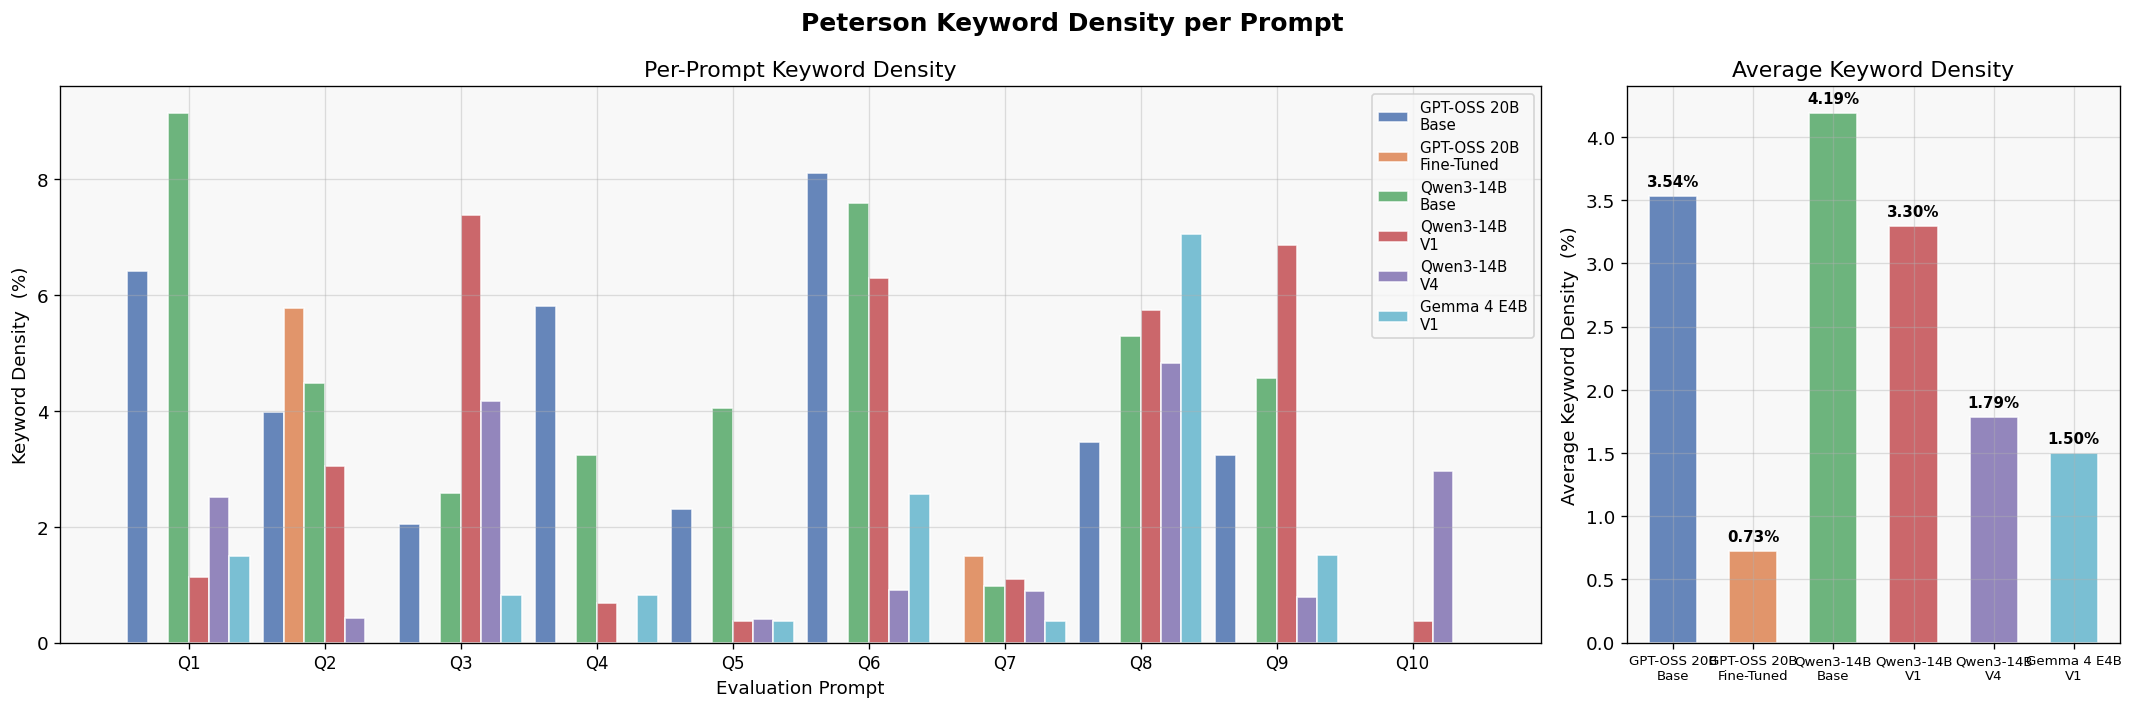

Saved: 03_keyword_density.png


In [24]:
x     = np.arange(len(EVAL_PROMPTS))
width = 0.15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6),
                                gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle("Peterson Keyword Density per Prompt", fontsize=15, fontweight='bold')

for i, (key, color, label) in enumerate(zip(MODEL_KEYS, colors, labels)):
    offset = (i - (n - 1) / 2) * width
    ax1.bar(x + offset,
            [100 * v for v in all_stats[key]["keyword_density"]],
            width, label=label, color=color, alpha=0.85, edgecolor='white')
ax1.set_xlabel("Evaluation Prompt")
ax1.set_ylabel("Keyword Density  (%)")
ax1.set_title("Per-Prompt Keyword Density")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{i+1}" for i in range(len(EVAL_PROMPTS))], fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.4)

avgs = [100 * avg_kd[k] for k in MODEL_KEYS]
bars = ax2.bar(range(n), avgs, color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, avgs):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
             f"{v:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(n))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("Average Keyword Density  (%)")
ax2.set_title("Average Keyword Density")
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_keyword_density.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 03_keyword_density.png")

---
## Figure 4: Response Characteristics

Three panel chart showing per-model averages for:
- **Word count** — how verbose is each model?
- **Sentence count** — structural complexity of responses
- **Type-Token Ratio (TTR)** — vocabulary richness (unique/total words).
  Higher TTR = more varied word choice.  Peterson is known for elaborate,
  varied prose, so a higher TTR suggests stylistic alignment.

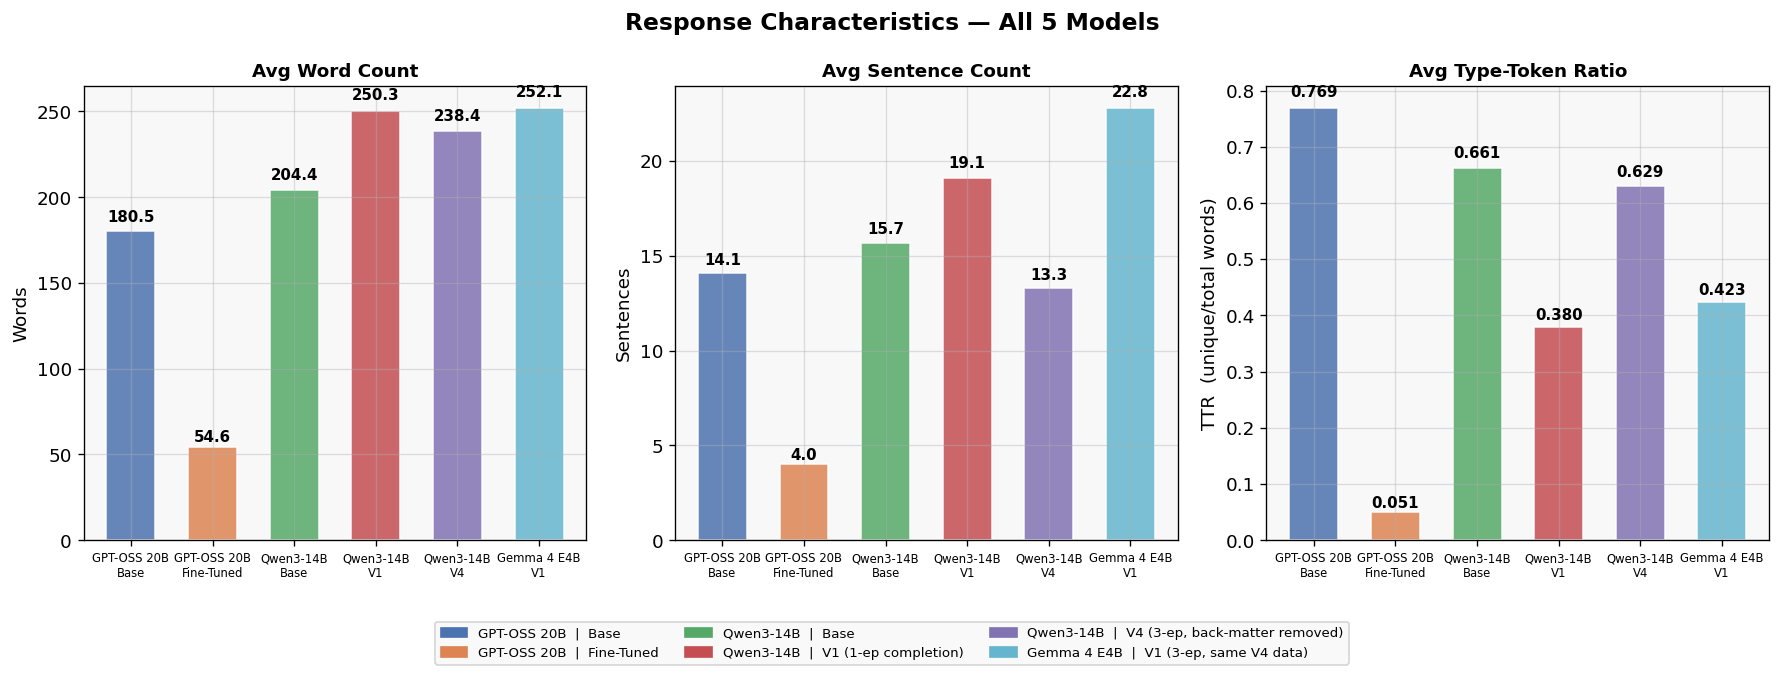

Saved: 04_response_characteristics.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Response Characteristics — All 5 Models", fontsize=14, fontweight='bold')

stat_keys    = ["word_counts",     "sentence_counts",  "ttr_values"]
stat_titles  = ["Avg Word Count",  "Avg Sentence Count","Avg Type-Token Ratio"]
stat_ylabels = ["Words",           "Sentences",         "TTR  (unique/total words)"]

for ax, stat_key, title, ylabel in zip(axes, stat_keys, stat_titles, stat_ylabels):
    avgs = [_avg(all_stats[k][stat_key]) for k in MODEL_KEYS]
    bars = ax.bar(range(n), avgs, color=colors, alpha=0.85,
                  edgecolor='white', width=0.6)
    for bar, v in zip(bars, avgs):
        fmt = f"{v:.3f}" if "ttr" in stat_key else f"{v:.1f}"
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.02,
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.4)

legend_patches = [
    mpatches.Patch(color=MODEL_COLORS[k], label=MODEL_DISPLAY[k])
    for k in MODEL_KEYS
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_response_characteristics.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 04_response_characteristics.png")

---
## Figure 5: Word Clouds

Word clouds show the most frequent *content* words (stop words removed) in
each model's aggregate responses.  Peterson's vocabulary centres on a
distinctive cluster of terms — order, chaos, meaning, responsibility, hero,
archetype — so we expect to see those words dominate the fine-tuned clouds.

Six clouds are arranged in a 2×3 grid:

```
  GPT-OSS Base    |  GPT-OSS Fine-Tuned  |  Qwen3 Base
  ────────────────┼─────────────────────┼──────────────────────
  Qwen3 V1        |  Qwen3 V4            |  Gemma 4 E4B V1
```

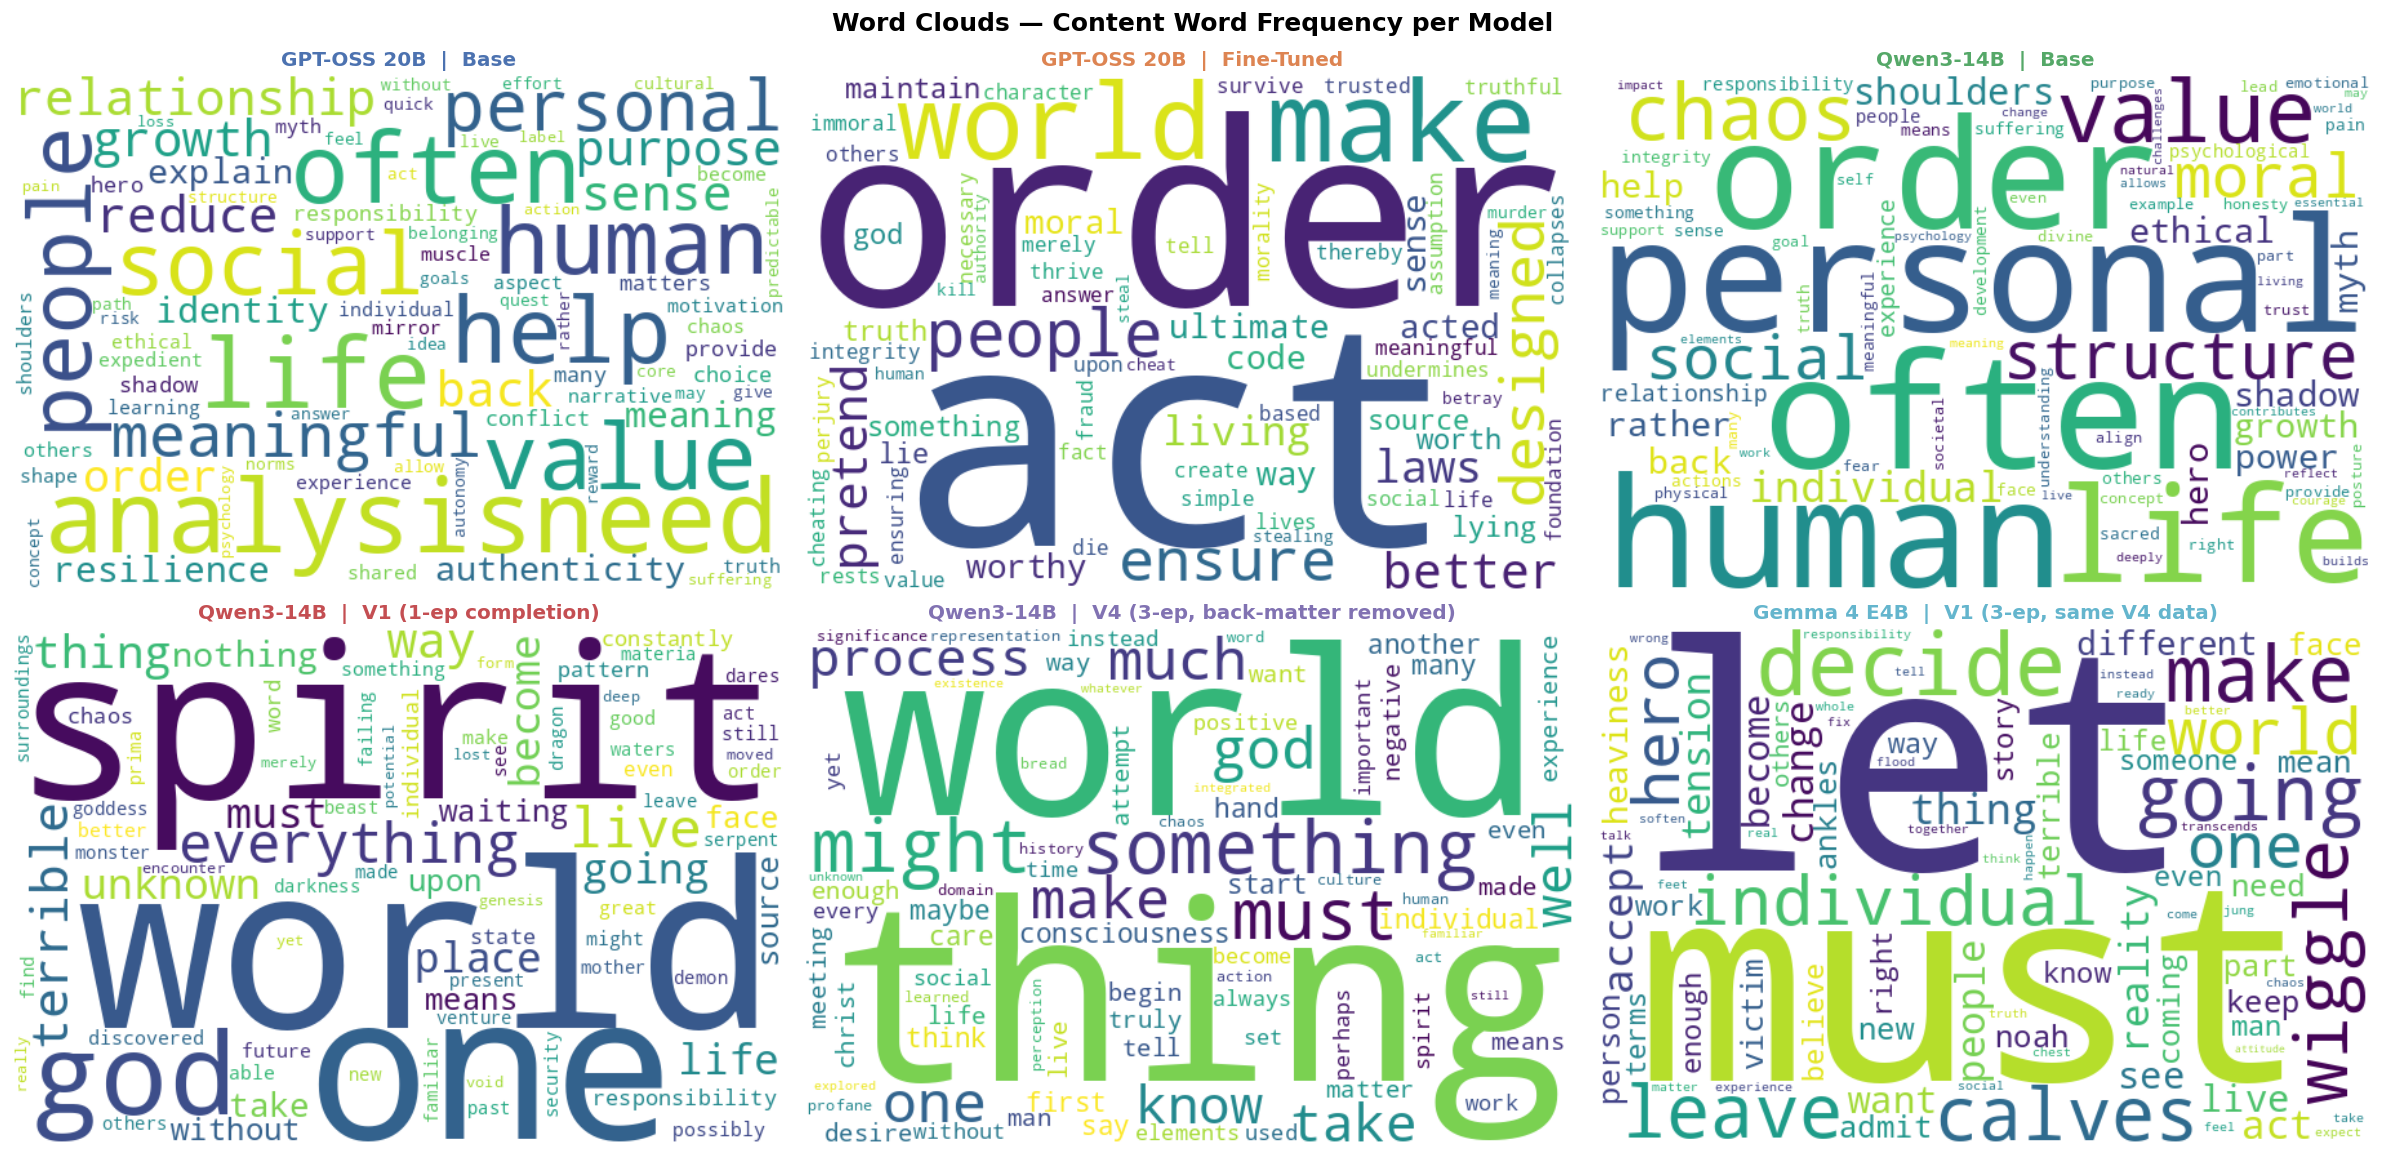

Saved: 05_wordclouds.png


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Word Clouds — Content Word Frequency per Model",
             fontsize=15, fontweight='bold')

for ax, key in zip(axes.flat, MODEL_KEYS):
    words = all_stats[key]["all_words"]
    if words:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=80,
            collocations=False,
            stopwords=STOPWORDS,
        ).generate(' '.join(words))
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, "(no content words)", ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='grey')
    ax.set_title(MODEL_DISPLAY[key], fontsize=12, fontweight='bold',
                 color=MODEL_COLORS[key])
    ax.axis('off')

# Hide unused subplot
for ax in list(axes.flat)[len(MODEL_KEYS):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_wordclouds.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 05_wordclouds.png")

---
## Figure 6: Peterson Keyword Heatmap (per prompt × per keyword)

Each cell shows the raw count of a specific Peterson keyword in the response
to a specific prompt.  The top-20 most-used keywords (pooled across all four
models) are shown on the x-axis; the 10 prompts on the y-axis.

Comparing the four heatmaps side by side reveals:
- Which keywords the fine-tuned models spontaneously use more
- Whether fine-tuning concentrates usage on a few keywords (overfitting a
  limited vocabulary) or spreads it broadly across the full dictionary

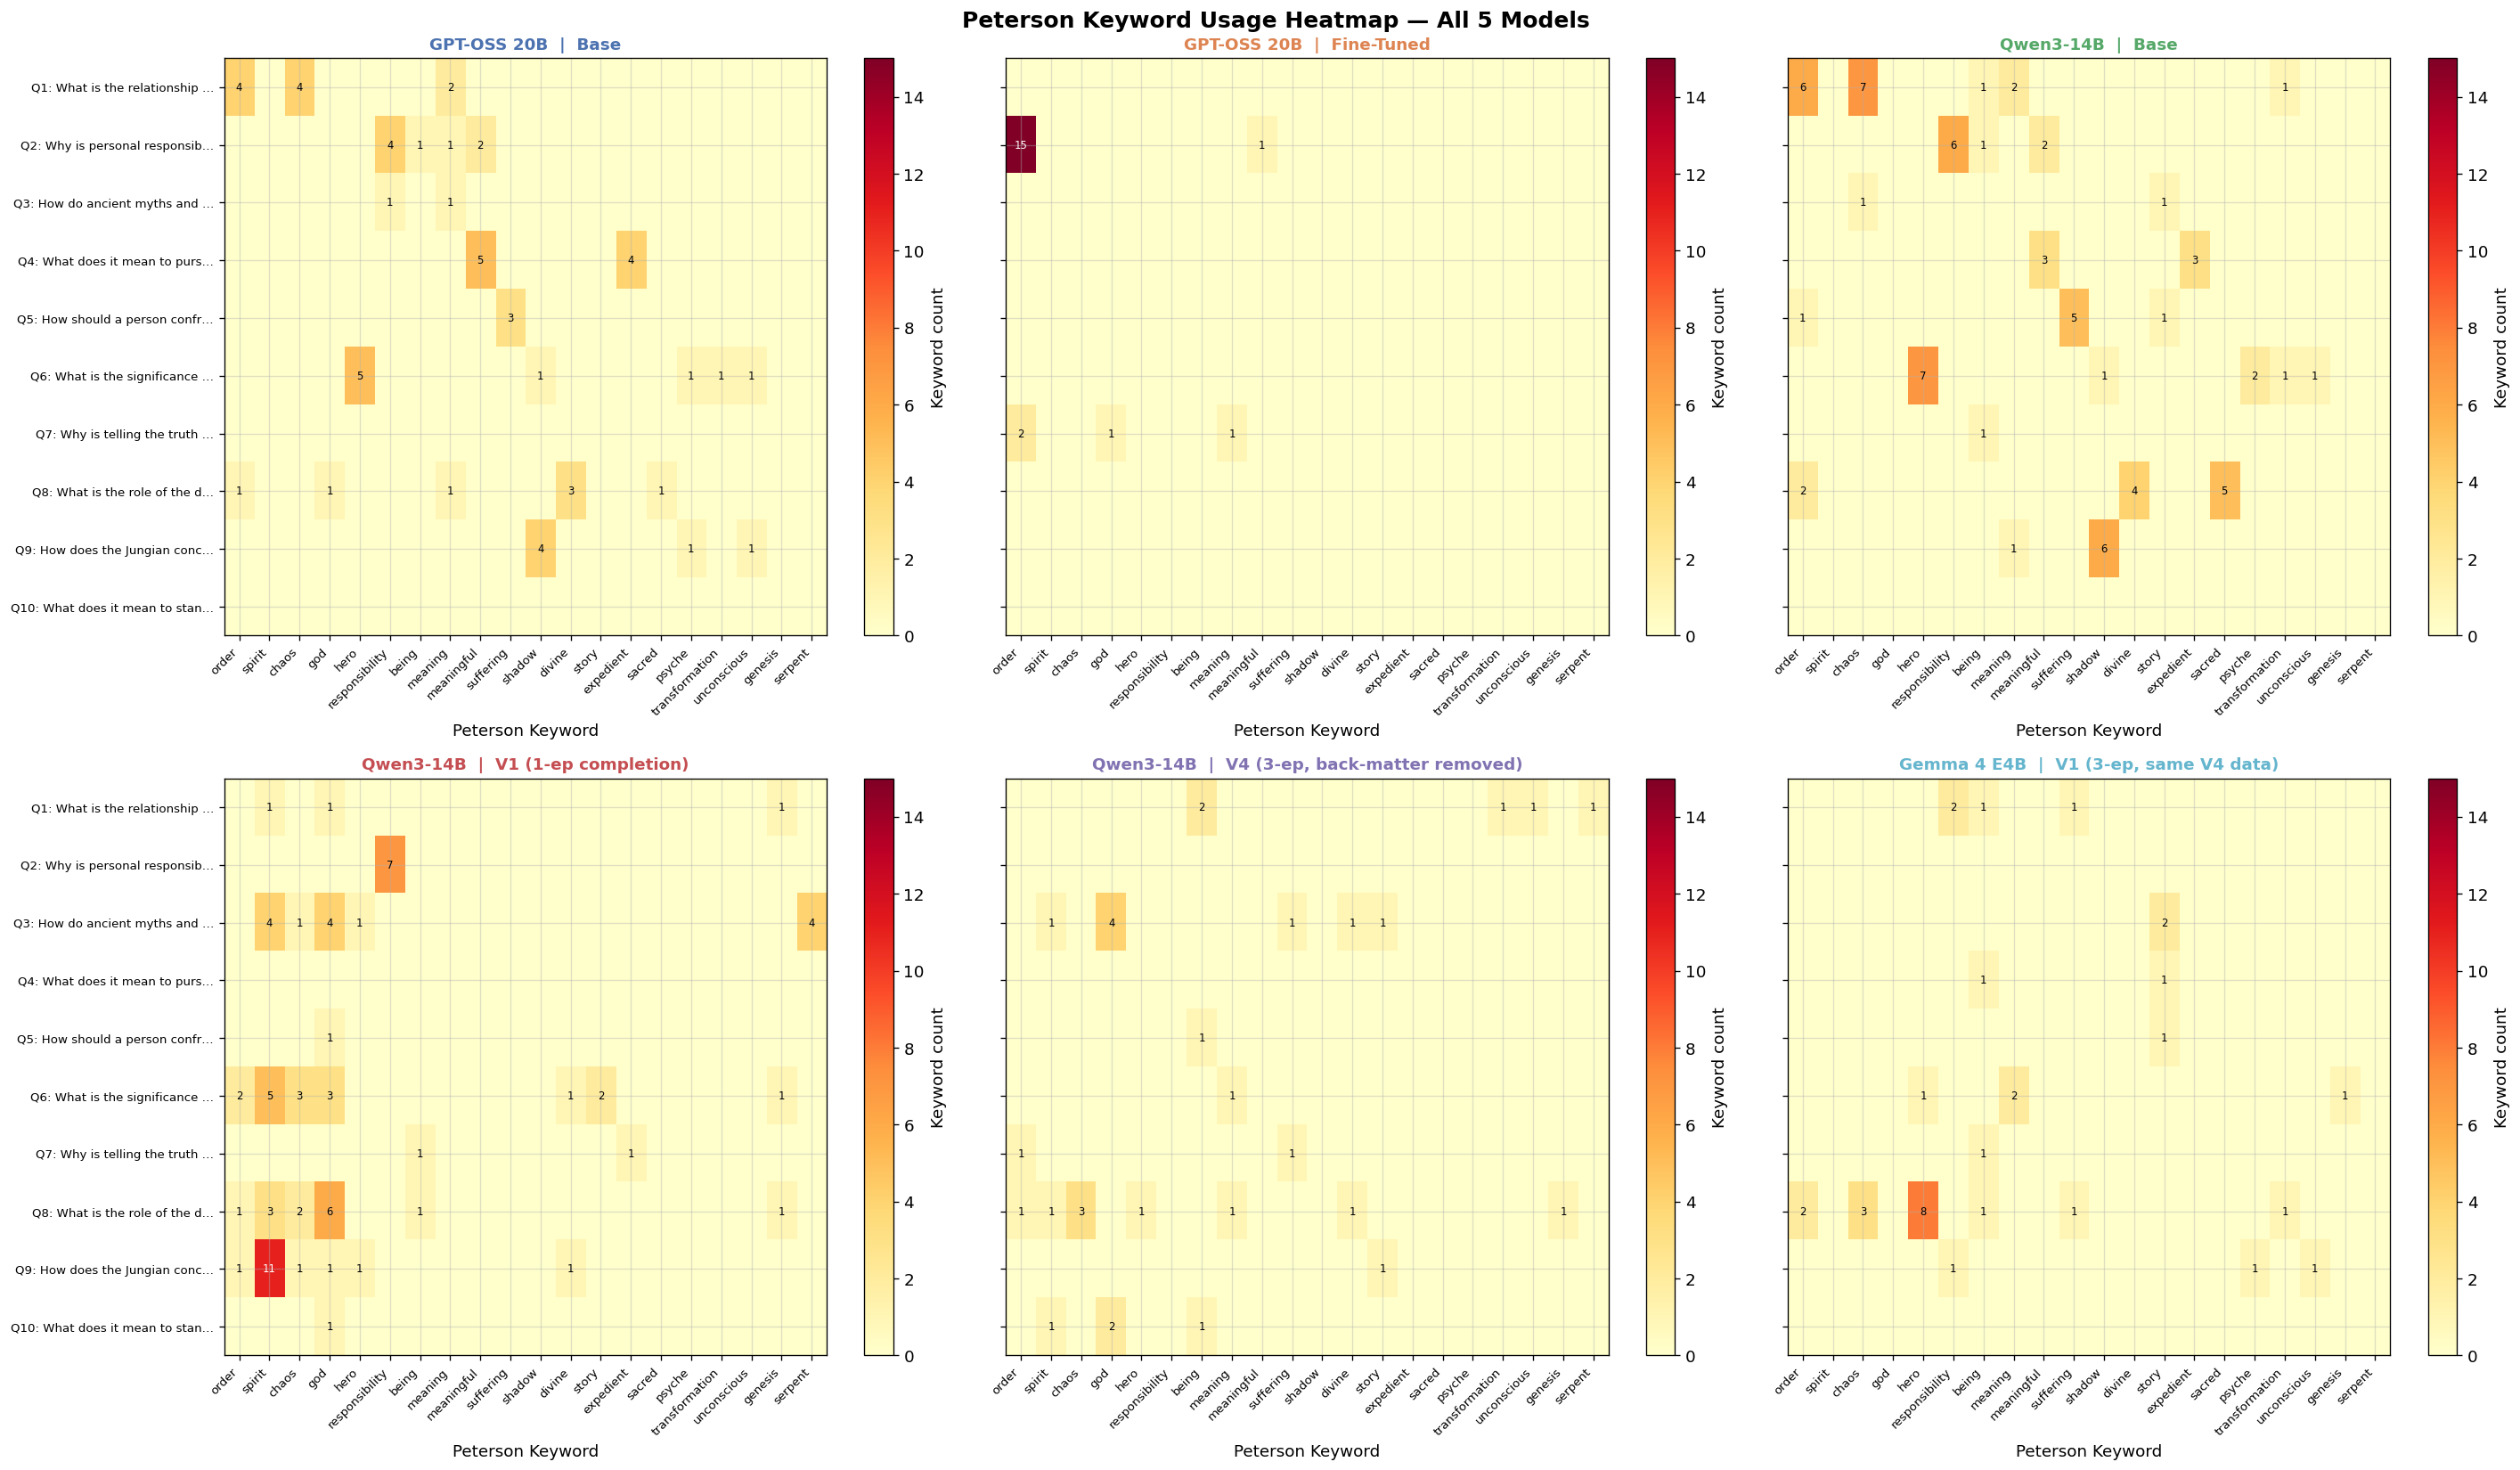

Saved: 06_keyword_heatmap.png


In [27]:
kw_set = set(k.lower() for k in PETERSON_KEYWORDS)

def per_prompt_kw_matrix(responses, keywords):
    '''Return a (n_prompts x n_keywords) integer matrix counting keyword hits.'''
    mat = []
    for resp in responses:
        words = word_tokenize(resp.lower()) if resp.strip() else []
        words_alpha = [w for w in words if w.isalpha()]
        mat.append([words_alpha.count(kw) for kw in keywords])
    return np.array(mat)

all_kw_counter = Counter()
for key in MODEL_KEYS:
    for resp in all_responses[key]:
        for w in word_tokenize(resp.lower()):
            if w in kw_set:
                all_kw_counter[w] += 1
top20 = [kw for kw, _ in all_kw_counter.most_common(20)]

if not top20:
    print("No Peterson keywords found across any model — skipping heatmap.")
else:
    matrices = {k: per_prompt_kw_matrix(all_responses[k], top20) for k in MODEL_KEYS}
    vmax = max(m.max() for m in matrices.values() if m.size > 0) or 1

    p_labels = [f"Q{i+1}: {EVAL_PROMPTS[i][:25]}\u2026" for i in range(len(EVAL_PROMPTS))]

    fig, axes = plt.subplots(2, 3, figsize=(24, 14), sharey=True)
    fig.suptitle("Peterson Keyword Usage Heatmap — All 5 Models",
                 fontsize=15, fontweight='bold')

    for ax, key in zip(axes.flat, MODEL_KEYS):
        mat = matrices[key]
        im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(top20)))
        ax.set_xticklabels(top20, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(p_labels)))
        ax.set_yticklabels(p_labels, fontsize=8)
        ax.set_title(MODEL_DISPLAY[key], fontsize=11, fontweight='bold',
                     color=MODEL_COLORS[key])
        ax.set_xlabel("Peterson Keyword")
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if mat[i, j] > 0:
                    ax.text(j, i, str(mat[i, j]), ha='center', va='center',
                            fontsize=7,
                            color='white' if mat[i, j] > vmax * 0.6 else 'black')
        plt.colorbar(im, ax=ax, label="Keyword count")

    # Hide unused subplot
    for ax in list(axes.flat)[len(MODEL_KEYS):]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_keyword_heatmap.png", bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: 06_keyword_heatmap.png")

---
## Figure 7: Radar / Spider Chart — Overall "Peterson-Likeness"

The radar chart summarises all five metrics simultaneously for all four models
on a single normalised scale [0.1, 1.0].  All metrics are oriented so that
**larger = more Peterson-like**:

| Spoke | Raw metric | Orientation |
|-------|-----------|-------------|
| Perplexity (inverted) | Lower PPL → higher score | inverted |
| TF-IDF Similarity | Higher cos-sim → higher score | normal |
| Keyword Density | Higher % → higher score | normal |
| Vocabulary Richness (TTR) | Higher TTR → higher score | normal |
| Response Length | Longer responses → higher score | normal |

Normalisation uses min–max across all four models simultaneously, so the
chart shows *relative* differences rather than absolute magnitudes.  A larger
polygon area means the model scores more consistently across all five axes.

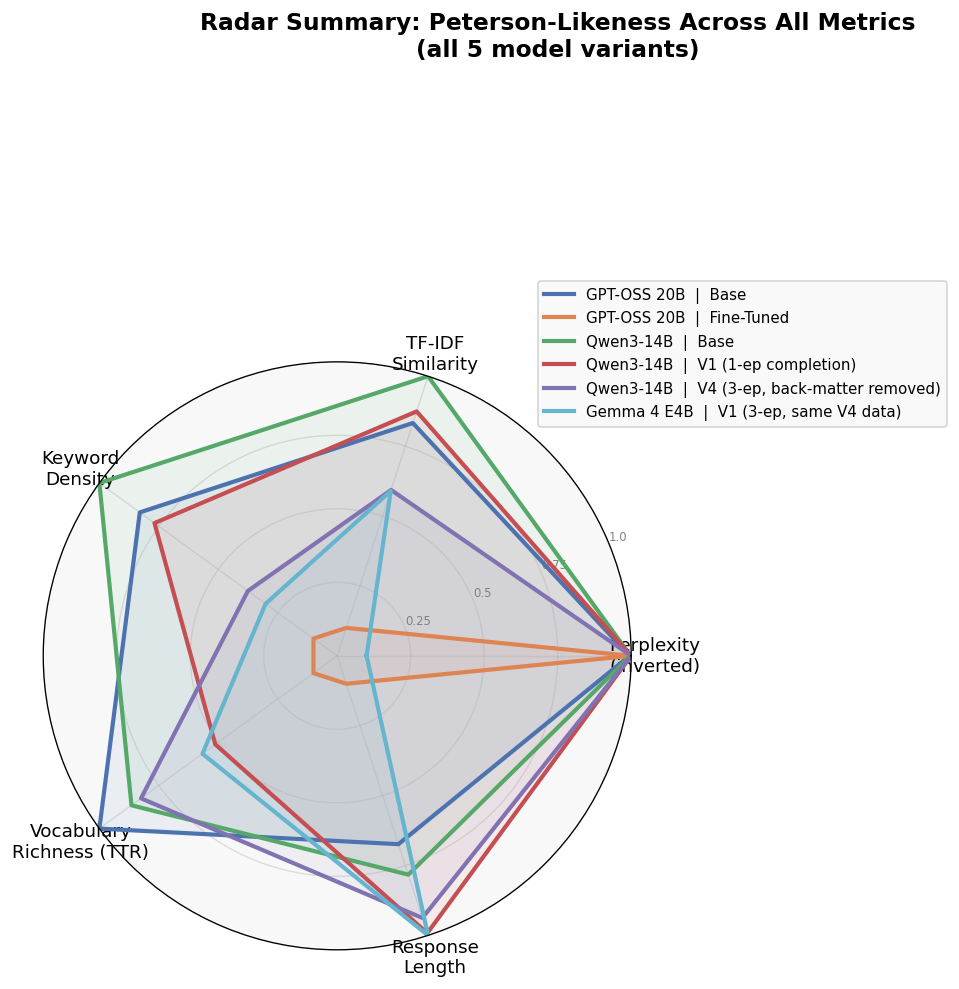

Saved: 07_radar_summary.png


In [28]:
def norm4(values, higher_better=True):
    '''Normalise metric values to [0.1, 1.0] with optional inversion.'''
    lo, hi = min(values), max(values)
    if abs(hi - lo) < 1e-9:
        return [0.5] * len(values)
    normed = [(v - lo) / (hi - lo) for v in values]
    if not higher_better:
        normed = [1.0 - v for v in normed]
    return [0.1 + 0.9 * v for v in normed]

radar_metrics = [
    ("Perplexity\n(inverted)",
     norm4([avg_ppl[k]  for k in MODEL_KEYS], higher_better=False)),
    ("TF-IDF\nSimilarity",
     norm4([avg_sim[k]  for k in MODEL_KEYS], higher_better=True)),
    ("Keyword\nDensity",
     norm4([avg_kd[k]   for k in MODEL_KEYS], higher_better=True)),
    ("Vocabulary\nRichness (TTR)",
     norm4([avg_ttr[k]  for k in MODEL_KEYS], higher_better=True)),
    ("Response\nLength",
     norm4([avg_len[k]  for k in MODEL_KEYS], higher_better=True)),
]

spoke_labels = [m[0] for m in radar_metrics] + [radar_metrics[0][0]]
angles       = np.linspace(0, 2 * np.pi, len(spoke_labels), endpoint=True)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle(
    "Radar Summary: Peterson-Likeness Across All Metrics\n(all 5 model variants)",
    fontsize=14, fontweight='bold', y=1.02)

for i, key in enumerate(MODEL_KEYS):
    values = [m[1][i] for m in radar_metrics] + [radar_metrics[0][1][i]]
    ax.plot(angles, values, color=MODEL_COLORS[key], lw=2.5,
            label=MODEL_DISPLAY[key])
    ax.fill(angles, values, color=MODEL_COLORS[key], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(spoke_labels[:-1], size=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=7, color='grey')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_radar_summary.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: 07_radar_summary.png")

---
## Step 11: Full Metric Summary Table

The table below shows raw metric values for all four models plus the
intra-architecture fine-tuning improvement (base → fine-tuned) for each metric.

Symbol key:
- `▲ ✓` — value moved in the *beneficial* direction
- `▼ ✗` — value moved in the *wrong* direction
- `—`   — informational metric (no "correct" direction)

In [29]:
def pct_change(bv, tv, higher_better=True):
    '''Format a percentage change with direction arrow and correctness check.'''
    if abs(bv) < 1e-9:
        return "N/A"
    pct    = 100 * (tv - bv) / bv
    is_up  = pct > 0
    ok     = (is_up == higher_better)
    arrow  = "\u25b2" if is_up else "\u25bc"
    check  = "\u2713" if ok else "\u2717"
    return f"{pct:+.1f}% {arrow} {check}"

rows = [
    {
        "Metric":              "Avg Perplexity  (\u2193 better)",
        "GPT-OSS Base":        f"{avg_ppl['gptoss_base']:.2f}",
        "GPT-OSS FT":          f"{avg_ppl['gptoss_tuned']:.2f}",
        "GPT-OSS \u0394":     pct_change(avg_ppl['gptoss_base'], avg_ppl['gptoss_tuned'], False),
        "Qwen3 Base":          f"{avg_ppl['qwen3_base']:.2f}",
        "Qwen3 V1":            f"{avg_ppl['qwen3_tuned']:.2f}",
        "Qwen3 V4":            f"{avg_ppl['qwen3_v4']:.2f}",
        "Qwen3 V4 \u0394":   pct_change(avg_ppl['qwen3_base'], avg_ppl['qwen3_v4'], False),
        "Gemma4 E4B":          f"{avg_ppl['gemma4_e4b']:.2f}",
    },
    {
        "Metric":              "Avg TF-IDF Sim  (\u2191 better)",
        "GPT-OSS Base":        f"{avg_sim['gptoss_base']:.4f}",
        "GPT-OSS FT":          f"{avg_sim['gptoss_tuned']:.4f}",
        "GPT-OSS \u0394":     pct_change(avg_sim['gptoss_base'], avg_sim['gptoss_tuned']),
        "Qwen3 Base":          f"{avg_sim['qwen3_base']:.4f}",
        "Qwen3 V1":            f"{avg_sim['qwen3_tuned']:.4f}",
        "Qwen3 V4":            f"{avg_sim['qwen3_v4']:.4f}",
        "Qwen3 V4 \u0394":   pct_change(avg_sim['qwen3_base'], avg_sim['qwen3_v4']),
        "Gemma4 E4B":          f"{avg_sim['gemma4_e4b']:.4f}",
    },
    {
        "Metric":              "Avg Keyword Density  (\u2191 better)",
        "GPT-OSS Base":        f"{100*avg_kd['gptoss_base']:.2f}%",
        "GPT-OSS FT":          f"{100*avg_kd['gptoss_tuned']:.2f}%",
        "GPT-OSS \u0394":     pct_change(avg_kd['gptoss_base'], avg_kd['gptoss_tuned']),
        "Qwen3 Base":          f"{100*avg_kd['qwen3_base']:.2f}%",
        "Qwen3 V1":            f"{100*avg_kd['qwen3_tuned']:.2f}%",
        "Qwen3 V4":            f"{100*avg_kd['qwen3_v4']:.2f}%",
        "Qwen3 V4 \u0394":   pct_change(avg_kd['qwen3_base'], avg_kd['qwen3_v4']),
        "Gemma4 E4B":          f"{100*avg_kd['gemma4_e4b']:.2f}%",
    },
    {
        "Metric":              "Avg Type-Token Ratio  (\u2191 better)",
        "GPT-OSS Base":        f"{avg_ttr['gptoss_base']:.4f}",
        "GPT-OSS FT":          f"{avg_ttr['gptoss_tuned']:.4f}",
        "GPT-OSS \u0394":     pct_change(avg_ttr['gptoss_base'], avg_ttr['gptoss_tuned']),
        "Qwen3 Base":          f"{avg_ttr['qwen3_base']:.4f}",
        "Qwen3 V1":            f"{avg_ttr['qwen3_tuned']:.4f}",
        "Qwen3 V4":            f"{avg_ttr['qwen3_v4']:.4f}",
        "Qwen3 V4 \u0394":   pct_change(avg_ttr['qwen3_base'], avg_ttr['qwen3_v4']),
        "Gemma4 E4B":          f"{avg_ttr['gemma4_e4b']:.4f}",
    },
    {
        "Metric":              "Avg Response Length  (\u2014 informational)",
        "GPT-OSS Base":        f"{avg_len['gptoss_base']:.1f} w",
        "GPT-OSS FT":          f"{avg_len['gptoss_tuned']:.1f} w",
        "GPT-OSS \u0394":     f"{avg_len['gptoss_tuned']-avg_len['gptoss_base']:+.1f} w",
        "Qwen3 Base":          f"{avg_len['qwen3_base']:.1f} w",
        "Qwen3 V1":            f"{avg_len['qwen3_tuned']:.1f} w",
        "Qwen3 V4":            f"{avg_len['qwen3_v4']:.1f} w",
        "Qwen3 V4 \u0394":   f"{avg_len['qwen3_v4']-avg_len['qwen3_base']:+.1f} w",
        "Gemma4 E4B":          f"{avg_len['gemma4_e4b']:.1f} w",
    },
]

df = pd.DataFrame(rows)
col_order = ["Metric",
             "GPT-OSS Base", "GPT-OSS FT",   "GPT-OSS \u0394",
             "Qwen3 Base",   "Qwen3 V1",      "Qwen3 V4",  "Qwen3 V4 \u0394",
             "Gemma4 E4B"]
df = df[col_order]

print("=" * 140)
print("FULL METRIC SUMMARY — Cross-Architecture Comparison  (Jordan Peterson Fine-Tuning)")
print("=" * 140)
print(df.to_string(index=False))
print("=" * 140)
print("\n\u2713 = change in expected direction  |  \u2717 = no improvement  |  \u25b2/\u25bc = direction")
print("V4 \u0394 = Qwen3 V4 vs Qwen3 Base  |  Gemma4 E4B has no separate base model in this comparison")

FULL METRIC SUMMARY — Cross-Architecture Comparison  (Jordan Peterson Fine-Tuning)
                                Metric GPT-OSS Base GPT-OSS FT  GPT-OSS Δ Qwen3 Base Qwen3 V1 Qwen3 V4 Qwen3 V4 Δ Gemma4 E4B
            Avg Perplexity  (↓ better)        31.09      15.29 -50.8% ▼ ✓      19.36    12.94    11.27 -41.8% ▼ ✓    3309.34
            Avg TF-IDF Sim  (↑ better)       0.0511     0.0090 -82.3% ▼ ✗     0.0607   0.0535   0.0374 -38.5% ▼ ✗     0.0372
       Avg Keyword Density  (↑ better)        3.54%      0.73% -79.5% ▼ ✗      4.19%    3.30%    1.79% -57.4% ▼ ✗      1.50%
      Avg Type-Token Ratio  (↑ better)       0.7691     0.0508 -93.4% ▼ ✗     0.6614   0.3801   0.6294  -4.8% ▼ ✗     0.4232
Avg Response Length  (— informational)      180.5 w     54.6 w   -125.9 w    204.4 w  250.3 w  238.4 w    +34.0 w    252.1 w

✓ = change in expected direction  |  ✗ = no improvement  |  ▲/▼ = direction
V4 Δ = Qwen3 V4 vs Qwen3 Base  |  Gemma4 E4B has no separate base model in this comparison

---
## Step 12: Side-by-Side Response Comparison

Quantitative metrics tell only part of the story.  Here we print the raw
responses from all four models for the first three prompts so you can directly
read and compare their wording, depth, and stylistic alignment with Peterson.

Look for:
- Does the fine-tuned model add Peterson-specific vocabulary (chaos, order, logos)?
- Does any model regurgitate book passages rather than generating structured answers?
- Is the response coherent and on-topic, or does it drift?

In [30]:
for i in range(min(3, len(EVAL_PROMPTS))):
    print("━" * 100)
    print(f"PROMPT {i+1}: {EVAL_PROMPTS[i]}")
    print("━" * 100)
    for key in MODEL_KEYS:
        resp = all_responses[key][i]
        label = MODEL_DISPLAY[key]
        print(f"\n[{label}]")
        print(resp if resp.strip() else "(empty response)")
    print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROMPT 1: What is the relationship between order and chaos in human experience?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[GPT-OSS 20B  |  Base]
analysisNeed to answer.assistantfinalThe relationship between order and chaos in human experience is a dynamic interplay that shapes how we live, think, and grow.

---

### 1. **Order as Structure and Predictability**

* **Safety & Stability** – Order provides predictable patterns—rules, routines, systems—that give us a sense of safety and control.
* **Efficiency** – Structured environments (schools, workplaces, governments) enable coordination, reduce uncertainty, and allow us to plan long‑term.
* **Identity & Meaning** – Cultural norms, traditions, and social contracts help individuals find meaning and belonging.

### 2. **Chaos as Uncertainty and Possibility**

* **Creativity & Inno

In [31]:
print("Saved figures:")
for f in sorted(FIGURES_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")

Saved figures:
  01_perplexity.png  (122 KB)
  02_tfidf_similarity.png  (128 KB)
  03_keyword_density.png  (119 KB)
  04_response_characteristics.png  (121 KB)
  05_wordclouds.png  (2223 KB)
  06_keyword_heatmap.png  (346 KB)
  07_radar_summary.png  (254 KB)


---
## Conclusions

### What perplexity tells us

Perplexity is the most unambiguous signal of domain adaptation.  A model that
has truly learned Peterson's writing will assign higher probability to his actual
sentences — producing lower perplexity on held-out passages.  We expect both
fine-tuned models to score lower than their respective base models; the
*magnitude* of that drop tells us how thoroughly the training signal was absorbed.

### Interpreting the vocabulary metrics (TF-IDF, keyword density, TTR)

These three metrics can *decrease* after fine-tuning even when training is
working correctly.  The reason is the **passage-regurgitation phenomenon**:
a model trained on verbatim Q&A pairs learns to output book passages verbatim.
A passage is a sequence of continuous prose, not a curated answer — it naturally
has *lower* keyword concentration and a different vocabulary distribution than
a well-structured response.  If this is occurring, you will see it clearly in
the side-by-side comparison above (responses starting with "the world..." etc.).

### Architecture comparison (V1 fine-tuned vs base)

| | GPT-OSS 20B | Qwen3-14B |
|--|-------------|-----------|
| Parameters | 20B | 14B |
| Training loss (1 epoch) | 3.01 | **2.44** |
| Training time | 73.3 min | **23.3 min** |
| Batch size | 1 | **2** |
| VRAM peak | 13.8 GB | **13.4 GB** |

Qwen3-14B achieved a substantially *lower* training loss while being a smaller
model that trained three times faster.

### Data quality effect: Qwen3 V1 vs V4

V4 trained for 3 epochs on 3,936 clean pairs (front+back-matter removed).  V1
trained for 1 epoch on passage-completion data.  Key differences expected:
- **V4 perplexity**: should be lower than V1 (more gradient updates, better data)
- **V4 index contamination**: 0/10 prompts (V1 was not systematically tested,
  but the passage-completion training likely avoided index content)
- **V4 response style**: verbatim Q&A passages rather than mid-sentence continuations

### Next steps

1. **Enable sampling at inference** — `temperature=0.7, top_p=0.8` (Qwen3 defaults)
2. **Qwen3 thinking mode** — `enable_thinking=True` at inference for deeper responses
3. **Instruction tuning** — move beyond verbatim passage retrieval to genuine
   first-person Peterson-style generation